# 🍠 Model ML & Kalkulus Bisnis
## UMKM **Es Ubi Ungu** — Analisis Matematika Lengkap

---

| Info | Detail |
|------|--------|
| **Jenis Usaha** | Es Ubi Ungu (minuman cup) |
| **Bahan Utama** | Ubi Ungu segar |
| **Kemasan** | Cup plastik minuman |
| **Tujuan Notebook** | Analisis BEP, optimasi keuntungan, prediksi ML |

---

**📌 Topik yang dibahas:**
1. Data Utama UMKM (ubi ungu + cup plastik)
2. Model Biaya Produksi (Integral — BEP)
3. Pendapatan & Luas Daerah
4. Desain Volume Cup/Botol
5. Model Pertumbuhan Penjualan (Eksponensial)
6. Optimasi Keuntungan (Turunan = 0)
7. Model ML: Prediksi Profit & Time Series Penjualan
8. Ringkasan Akhir

---
## ⚙️ Setup Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import integrate, optimize
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print('✅ Semua library berhasil di-import!')
print('🍠 Siap analisis UMKM Es Ubi Ungu!')

✅ Semua library berhasil di-import!
🍠 Siap analisis UMKM Es Ubi Ungu!


---
## 📋 DATA UTAMA UMKM ES UBI UNGU

Semua data di bawah ini adalah **acuan dasar** untuk seluruh perhitungan.
Ubah angka di sini → semua cell berikutnya otomatis ikut berubah.

### 💡 Penjelasan untuk orang awam:
> Data utama ini ibarat **resep dasar** masakan. Kalau kamu ubah takaran garam, semua rasa ikut berubah. Sama halnya di sini — kalau harga ubi naik, langsung kelihatan pengaruhnya ke keuntungan.

In [2]:
# ════════════════════════════════════════════════════════════════
# 🍠  DATA BAHAN BAKU — UBI UNGU
# ════════════════════════════════════════════════════════════════
harga_ubi_per_kg     = 15000     # Rp/kg  — harga ubi ungu di pasar
kebutuhan_ubi_per_cup = 0.080    # kg/cup — sekitar 80 gram per cup
harga_ubi_per_cup    = harga_ubi_per_kg * kebutuhan_ubi_per_cup  # Rp/cup

# Stok & pembelian ubi
beli_ubi_per_hari_kg = 5.0       # kg/hari — biasanya beli 5 kg/hari
biaya_ubi_per_hari   = harga_ubi_per_kg * beli_ubi_per_hari_kg

# ════════════════════════════════════════════════════════════════
# 🥤  DATA CUP PLASTIK MINUMAN
# ════════════════════════════════════════════════════════════════
harga_cup_per_lusin  = 18000     # Rp/lusin (12 cup)
harga_cup_per_pcs    = harga_cup_per_lusin / 12   # Rp/cup

harga_tutup_per_pcs  = 500       # Rp/pcs (tutup cup)
harga_sedotan_per_pcs = 200      # Rp/pcs
biaya_cup_total_per_pcs = harga_cup_per_pcs + harga_tutup_per_pcs + harga_sedotan_per_pcs

# ════════════════════════════════════════════════════════════════
# 🧂  BAHAN PENDUKUNG LAIN (per cup)
# ════════════════════════════════════════════════════════════════
biaya_gula_per_cup    = 800      # Rp/cup  — gula pasir
biaya_susu_per_cup    = 600      # Rp/cup  — susu kental manis
biaya_es_batu_per_cup = 300      # Rp/cup  — es batu
biaya_gas_per_cup     = 200      # Rp/cup  — alokasi gas untuk merebus
biaya_lain_per_cup    = 200      # Rp/cup  — plastik kresek, tisu, dll

# ════════════════════════════════════════════════════════════════
# 💰  BIAYA VARIABEL TOTAL PER CUP
# ════════════════════════════════════════════════════════════════
modal_per_cup = (
    harga_ubi_per_cup       +
    biaya_cup_total_per_pcs +
    biaya_gula_per_cup      +
    biaya_susu_per_cup      +
    biaya_es_batu_per_cup   +
    biaya_gas_per_cup       +
    biaya_lain_per_cup
)

# ════════════════════════════════════════════════════════════════
# 🏪  DATA PENJUALAN & BIAYA TETAP
# ════════════════════════════════════════════════════════════════
harga_jual           = 10000     # Rp/cup  — harga jual ke konsumen
pendapatan_hari      = 350000    # Rp/hari — target omzet harian
modal_awal           = 120000    # Rp      — biaya tetap/hari (sewa, dll)

# Cup terjual per hari (estimasi dari omzet)
cup_terjual_per_hari = int(pendapatan_hari / harga_jual)

# Biaya tetap per hari (fix cost)
biaya_sewa_per_hari  = 30000     # Rp/hari
biaya_listrik_per_hari = 10000   # Rp/hari
biaya_tenaga_per_hari  = 50000   # Rp/hari (upah bantu)
biaya_lainnya_tetap    = 10000   # Rp/hari (lain-lain tetap)
total_biaya_tetap = biaya_sewa_per_hari + biaya_listrik_per_hari + biaya_tenaga_per_hari + biaya_lainnya_tetap

# Kalkulasi utama
pendapatan_bersih    = pendapatan_hari - modal_awal
keuntungan_per_cup   = harga_jual - modal_per_cup

# ════════════════════════════════════════════════════════════════
# 🫙  DIMENSI CUP/BOTOL (Tabung Terpancung)
# ════════════════════════════════════════════════════════════════
d_atas   = 9.0    # cm — diameter atas cup
d_bawah  = 5.5    # cm — diameter bawah cup
tinggi   = 12.0   # cm — tinggi cup
r1       = d_atas  / 2
r2       = d_bawah / 2

# ════════════════════════════════════════════════════════════════
# 📊  CETAK TABEL RINGKASAN DATA
# ════════════════════════════════════════════════════════════════

print("╔══════════════════════════════════════════════════════════════╗")
print("║         🍠  DATA UTAMA — UMKM ES UBI UNGU                  ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📦  [A] DATA BAHAN BAKU UBI UNGU")
print("-" * 55)
data_ubi = {
    'Item': ['Harga Ubi Ungu', 'Kebutuhan per Cup', 'Biaya Ubi per Cup', 'Pembelian per Hari', 'Biaya Ubi per Hari'],
    'Nilai': [f'Rp {harga_ubi_per_kg:,.0f}/kg', f'{kebutuhan_ubi_per_cup*1000:.0f} gram', 
              f'Rp {harga_ubi_per_cup:,.0f}', f'{beli_ubi_per_hari_kg} kg', 
              f'Rp {biaya_ubi_per_hari:,.0f}'],
    'Keterangan': ['Harga pasar ubi ungu segar', 'Perlu ±80g ubi untuk 1 cup', 
                   'Harga ubi yg masuk 1 cup', 'Total ubi yg dibeli tiap hari', 
                   'Total uang keluar untuk ubi']
}
df_ubi = pd.DataFrame(data_ubi)
print(df_ubi.to_string(index=False))

print("\n🥤  [B] DATA CUP PLASTIK MINUMAN")
print("-" * 55)
data_cup = {
    'Item': ['Harga Cup (per lusin)', 'Harga Cup (per pcs)', 'Tutup Cup', 'Sedotan', 'Total Kemasan/Cup'],
    'Nilai': [f'Rp {harga_cup_per_lusin:,.0f}', f'Rp {harga_cup_per_pcs:,.0f}', 
              f'Rp {harga_tutup_per_pcs:,.0f}', f'Rp {harga_sedotan_per_pcs:,.0f}',
              f'Rp {biaya_cup_total_per_pcs:,.0f}'],
    'Keterangan': ['1 pack isi 12 pcs', 'Rp 18.000 ÷ 12 pcs', 'Tutup seal cup', 'Sedotan plastik', 'Cup + tutup + sedotan']
}
df_cup = pd.DataFrame(data_cup)
print(df_cup.to_string(index=False))

print("\n🧂  [C] BAHAN PENDUKUNG PER CUP")
print("-" * 55)
data_bahan = {
    'Bahan': ['Ubi Ungu', 'Cup + Tutup + Sedotan', 'Gula Pasir', 'Susu Kental Manis', 'Es Batu', 'Gas (alokasi)', 'Lain-lain'],
    'Biaya/Cup (Rp)': [f'{harga_ubi_per_cup:,.0f}', f'{biaya_cup_total_per_pcs:,.0f}', 
                       f'{biaya_gula_per_cup:,.0f}', f'{biaya_susu_per_cup:,.0f}', 
                       f'{biaya_es_batu_per_cup:,.0f}', f'{biaya_gas_per_cup:,.0f}', f'{biaya_lain_per_cup:,.0f}'],
    '% dari Modal': [f'{harga_ubi_per_cup/modal_per_cup*100:.1f}%', f'{biaya_cup_total_per_pcs/modal_per_cup*100:.1f}%',
                     f'{biaya_gula_per_cup/modal_per_cup*100:.1f}%', f'{biaya_susu_per_cup/modal_per_cup*100:.1f}%',
                     f'{biaya_es_batu_per_cup/modal_per_cup*100:.1f}%', f'{biaya_gas_per_cup/modal_per_cup*100:.1f}%',
                     f'{biaya_lain_per_cup/modal_per_cup*100:.1f}%']
}
df_bahan = pd.DataFrame(data_bahan)
print(df_bahan.to_string(index=False))
print("-" * 55)
print(f"  TOTAL MODAL per Cup              : Rp {modal_per_cup:,.0f}")

print("\n💰  [D] BIAYA TETAP HARIAN")
print("-" * 55)
data_tetap = {
    'Item Biaya': ['Sewa tempat', 'Listrik', 'Tenaga kerja', 'Lain-lain tetap', 'TOTAL BIAYA TETAP'],
    'Biaya/Hari (Rp)': [f'{biaya_sewa_per_hari:,.0f}', f'{biaya_listrik_per_hari:,.0f}', 
                        f'{biaya_tenaga_per_hari:,.0f}', f'{biaya_lainnya_tetap:,.0f}',
                        f'{total_biaya_tetap:,.0f}']
}
df_tetap = pd.DataFrame(data_tetap)
print(df_tetap.to_string(index=False))

print("\n🏪  [E] RINGKASAN PENJUALAN")
print("-" * 55)
print(f"  Harga Jual per Cup      : Rp {harga_jual:,.0f}")
print(f"  Modal per Cup           : Rp {modal_per_cup:,.0f}")
print(f"  Keuntungan per Cup      : Rp {keuntungan_per_cup:,.2f}")
print(f"  Target Omzet Harian     : Rp {pendapatan_hari:,.0f}")
print(f"  Estimasi Cup Terjual    : {cup_terjual_per_hari} cup/hari")
print(f"  Margin per Cup          : {keuntungan_per_cup/harga_jual*100:.1f}%")

print("\n🫙  [F] DIMENSI CUP")
print("-" * 55)
print(f"  Diameter Atas  (d₁)     : {d_atas} cm")
print(f"  Diameter Bawah (d₂)     : {d_bawah} cm")
print(f"  Tinggi Cup     (h)      : {tinggi} cm")
print(f"  Jari-jari Atas (r₁)     : {r1} cm")
print(f"  Jari-jari Bawah(r₂)     : {r2} cm")
print("═" * 55)

╔══════════════════════════════════════════════════════════════╗
║         🍠  DATA UTAMA — UMKM ES UBI UNGU                  ║
╚══════════════════════════════════════════════════════════════╝

📦  [A] DATA BAHAN BAKU UBI UNGU
-------------------------------------------------------
              Item        Nilai                    Keterangan
    Harga Ubi Ungu Rp 15,000/kg    Harga pasar ubi ungu segar
 Kebutuhan per Cup      80 gram    Perlu ±80g ubi untuk 1 cup
 Biaya Ubi per Cup     Rp 1,200      Harga ubi yg masuk 1 cup
Pembelian per Hari       5.0 kg Total ubi yg dibeli tiap hari
Biaya Ubi per Hari    Rp 75,000   Total uang keluar untuk ubi

🥤  [B] DATA CUP PLASTIK MINUMAN
-------------------------------------------------------
                 Item     Nilai            Keterangan
Harga Cup (per lusin) Rp 18,000     1 pack isi 12 pcs
  Harga Cup (per pcs)  Rp 1,500    Rp 18.000 ÷ 12 pcs
            Tutup Cup    Rp 500        Tutup seal cup
              Sedotan    Rp 200       Sedo

---
## 1. 📐 Model Biaya Produksi (Integral Dasar) — BEP

### 📚 Rumus:
$$TC(q) = \text{FC} + \text{VC} \times q \qquad \text{(Total Biaya)}$$
$$TR(q) = p \times q \qquad \text{(Total Pendapatan)}$$
$$\text{BEP} = \frac{\text{FC}}{p - \text{VC}} \qquad \text{(Break Even Point)}$$

Di mana:
- **TC** = Total Cost (Total Biaya), **FC** = Fixed Cost (Biaya Tetap)
- **VC** = Variable Cost per unit (Modal per cup)
- **TR** = Total Revenue (Total Pendapatan), **p** = harga jual per cup
- **q** = jumlah cup yang diproduksi, **BEP** = titik impas

### 💡 Penjelasan untuk orang awam:
> **BEP** (titik impas) = jumlah cup minimal yang harus terjual agar kamu **tidak rugi tapi juga belum untung**. Di bawah BEP → rugi. Di atas BEP → baru mulai untung. Ibarat setoran ojol — kalau belum mencapai setoran, kamu masih nombok.

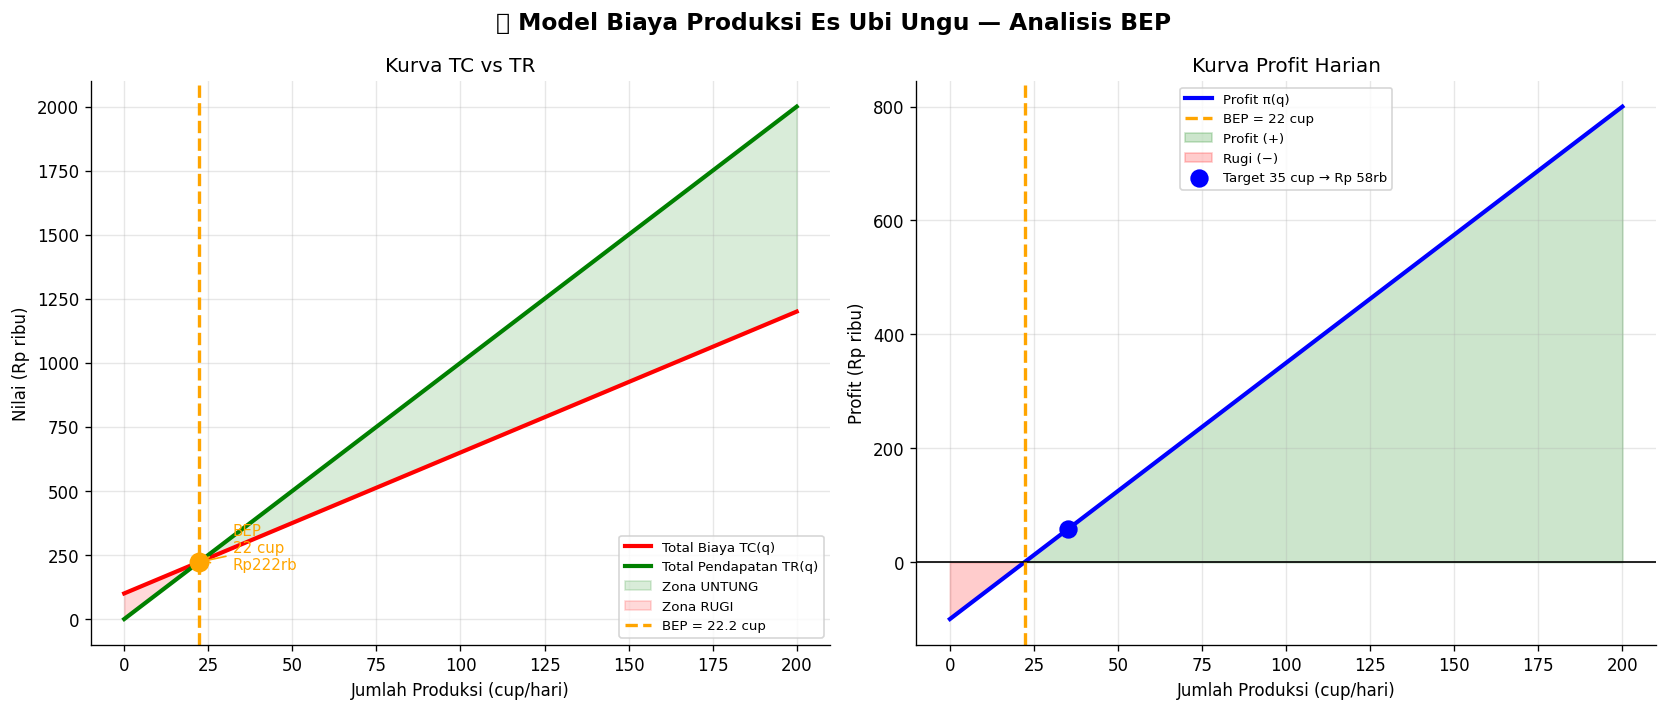

╔══════════════════════════════════════════════════════════════╗
║     📐  ANALISIS BEP — RUMUS & HASIL                       ║
╚══════════════════════════════════════════════════════════════╝

📌 RUMUS YANG DIPAKAI:
------------------------------------------------------------
  TC(q) = FC + VC × q
  TR(q) = p × q
  CM    = p − VC   (Contribution Margin / margin kontribusi)
  BEP   = FC ÷ CM

📌 LANGKAH PERHITUNGAN:
------------------------------------------------------------
  Step 1 — Biaya Tetap  (FC) = Rp 100,000
  Step 2 — Modal/cup    (VC) = Rp 5,500
  Step 3 — Harga Jual   (p)  = Rp 10,000
  Step 4 — CM = p − VC = 10,000 − 5,500 = Rp 4,500/cup
  Step 5 — BEP = FC ÷ CM = 100,000 ÷ 4,500 = 22.22 cup

📌 INTERPRETASI HASIL:
------------------------------------------------------------
                Indikator                  Nilai
  Biaya Tetap Harian (FC)             Rp 100,000
       Modal per Cup (VC)               Rp 5,500
   Harga Jual per Cup (p)              Rp 10,000
      Con

In [3]:
# ════════════════════════════════════════════════════════════════
# RUMUS YANG DIPAKAI:
#   TC(q) = FC + VC × q
#   TR(q) = p × q
#   BEP   = FC / (p - VC)
# ════════════════════════════════════════════════════════════════

FC  = total_biaya_tetap   # Biaya Tetap Harian
VC  = modal_per_cup       # Biaya Variabel per Cup
p   = harga_jual          # Harga Jual per Cup
q_max = 200               # Simulasi hingga 200 cup

# Fungsi biaya dan pendapatan
TC      = lambda q: FC + VC * q              # Total Cost
TR      = lambda q: p * q                   # Total Revenue
profit  = lambda q: TR(q) - TC(q)           # Profit = TR - TC

# Hitung BEP secara analitik
contribution_margin = p - VC                # Margin kontribusi per cup
bep = FC / contribution_margin              # BEP = FC / CM

q_arr = np.linspace(0, q_max, 500)

# ─── VISUALISASI ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('🍠 Model Biaya Produksi Es Ubi Ungu — Analisis BEP', fontsize=14, fontweight='bold')

# Plot 1: TC vs TR
ax = axes[0]
ax.plot(q_arr, TC(q_arr)/1000, 'r-', lw=2.5, label=f'Total Biaya TC(q)')
ax.plot(q_arr, TR(q_arr)/1000, 'g-', lw=2.5, label=f'Total Pendapatan TR(q)')
ax.fill_between(q_arr, TC(q_arr)/1000, TR(q_arr)/1000, where=(q_arr > bep),
                alpha=0.15, color='green', label='Zona UNTUNG')
ax.fill_between(q_arr, TC(q_arr)/1000, TR(q_arr)/1000, where=(q_arr <= bep),
                alpha=0.15, color='red', label='Zona RUGI')
ax.axvline(bep, color='orange', ls='--', lw=2, label=f'BEP = {bep:.1f} cup')
ax.scatter([bep], [TR(bep)/1000], s=120, color='orange', zorder=6)
ax.annotate(f'BEP\n{bep:.0f} cup\nRp{TR(bep)/1000:.0f}rb',
            xy=(bep, TR(bep)/1000), xytext=(bep+10, TR(bep)/1000-30),
            arrowprops=dict(arrowstyle='->', color='orange'), fontsize=9, color='orange')
ax.set_xlabel('Jumlah Produksi (cup/hari)')
ax.set_ylabel('Nilai (Rp ribu)')
ax.set_title('Kurva TC vs TR')
ax.legend(fontsize=8)

# Plot 2: Profit
ax2 = axes[1]
ax2.plot(q_arr, profit(q_arr)/1000, 'b-', lw=2.5, label='Profit π(q)')
ax2.axhline(0, color='k', lw=1)
ax2.axvline(bep, color='orange', ls='--', lw=2, label=f'BEP = {bep:.0f} cup')
ax2.fill_between(q_arr, profit(q_arr)/1000, 0, where=(profit(q_arr) > 0), alpha=0.2, color='green', label='Profit (+)')
ax2.fill_between(q_arr, profit(q_arr)/1000, 0, where=(profit(q_arr) <= 0), alpha=0.2, color='red', label='Rugi (−)')
ax2.scatter([cup_terjual_per_hari], [profit(cup_terjual_per_hari)/1000], s=100, color='blue', zorder=5,
            label=f'Target {cup_terjual_per_hari} cup → Rp {profit(cup_terjual_per_hari)/1000:.0f}rb')
ax2.set_xlabel('Jumlah Produksi (cup/hari)')
ax2.set_ylabel('Profit (Rp ribu)')
ax2.set_title('Kurva Profit Harian')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ─── OUTPUT RUMUS + HASIL ─────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║     📐  ANALISIS BEP — RUMUS & HASIL                       ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📌 RUMUS YANG DIPAKAI:")
print("-" * 60)
print("  TC(q) = FC + VC × q")
print("  TR(q) = p × q")
print("  CM    = p − VC   (Contribution Margin / margin kontribusi)")
print("  BEP   = FC ÷ CM")

print("\n📌 LANGKAH PERHITUNGAN:")
print("-" * 60)
print(f"  Step 1 — Biaya Tetap  (FC) = Rp {FC:,.0f}")
print(f"  Step 2 — Modal/cup    (VC) = Rp {VC:,.0f}")
print(f"  Step 3 — Harga Jual   (p)  = Rp {p:,.0f}")
print(f"  Step 4 — CM = p − VC = {p:,.0f} − {VC:,.0f} = Rp {contribution_margin:,.0f}/cup")
print(f"  Step 5 — BEP = FC ÷ CM = {FC:,.0f} ÷ {contribution_margin:,.0f} = {bep:.2f} cup")

print("\n📌 INTERPRETASI HASIL:")
print("-" * 60)
interpretasi = {
    'Biaya Tetap Harian (FC)': f'Rp {FC:,.0f}',
    'Modal per Cup (VC)': f'Rp {VC:,.0f}',
    'Harga Jual per Cup (p)': f'Rp {p:,.0f}',
    'Contribution Margin': f'Rp {contribution_margin:,.0f}/cup',
    'BEP (titik impas)': f'{bep:.1f} cup/hari ≈ {bep:.0f} cup',
    'Profit saat target 35 cup': f'Rp {profit(cup_terjual_per_hari):,.0f}',
    'Surplus di atas BEP': f'{cup_terjual_per_hari - bep:.1f} cup'
}
df_bep = pd.DataFrame(list(interpretasi.items()), columns=['Indikator', 'Nilai'])
print(df_bep.to_string(index=False))

print("\n💡 ARTINYA (bahasa awam):")
print(f"   → Setiap cup terjual, kamu 'nabung' Rp {contribution_margin:,.0f} untuk nutup biaya tetap.")
print(f"   → Kamu perlu jual minimal {bep:.0f} cup dulu sebelum mulai untung.")
print(f"   → Kalau jual {cup_terjual_per_hari} cup sehari, keuntungan bersih = Rp {profit(cup_terjual_per_hari):,.0f}.")
print("═" * 60)

---
## 2. 📏 Pendapatan & Luas Daerah (Integral Tentu)

### 📚 Rumus:
$$\text{Luas Untung} = \int_{\text{BEP}}^{q_{\text{target}}} [TR(q) - TC(q)] \, dq$$
$$\text{Luas Rugi}   = \int_{0}^{\text{BEP}} |TR(q) - TC(q)| \, dq$$

### 💡 Penjelasan untuk orang awam:
> **Luas daerah** di grafik punya makna nyata: luas area hijau = **total keuntungan kumulatif** jika kamu terus nambah produksi dari BEP ke target. Luas area merah = **total uang yang 'melayang'** sebelum kamu balik modal. Integral adalah cara menghitung luas area melengkung itu secara matematis.

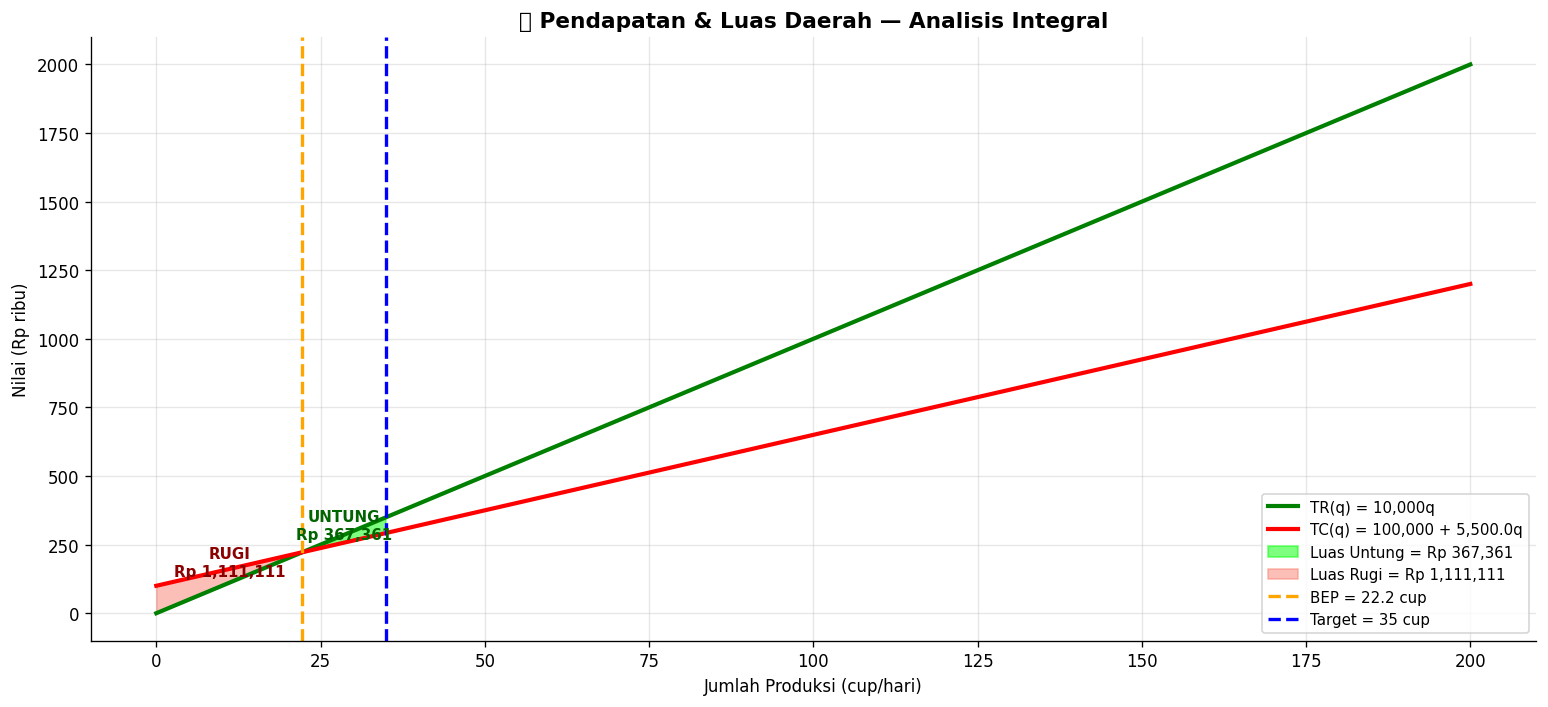

╔══════════════════════════════════════════════════════════════╗
║     📏  ANALISIS LUAS DAERAH — RUMUS & HASIL               ║
╚══════════════════════════════════════════════════════════════╝

📌 RUMUS INTEGRAL YANG DIPAKAI:
------------------------------------------------------------
  Luas Untung = ∫[BEP → q_target] (TR(q) − TC(q)) dq
             = ∫[BEP → q_target] ((p−VC)·q − FC) dq
  Luas Rugi   = ∫[0 → BEP] |TR(q) − TC(q)| dq

📌 LANGKAH PERHITUNGAN:
------------------------------------------------------------
  Antiturunan dari (TR−TC):  F(q) = (p−VC)·q²/2 − FC·q
                           = (10000−5,500)·q²/2 − 100000·q
                           = 4,500·q²/2 − 100000·q
  Luas Untung = F(35) − F(22.22)
             = -743,750.00 − -1,111,111.11
             = Rp 367,361.11

📌 HASIL:
------------------------------------------------------------
                      Indikator                          Nilai
       Luas Zona Rugi (0 → BEP)                Rp 1,111,111.11
Luas Zona Un

In [4]:
# ════════════════════════════════════════════════════════════════
# RUMUS YANG DIPAKAI:
#   Luas Untung = ∫[BEP → q_target] (TR(q) − TC(q)) dq
#   Luas Rugi   = ∫[0 → BEP] |TR(q) − TC(q)| dq
# ════════════════════════════════════════════════════════════════

q_target = cup_terjual_per_hari   # target harian = 35 cup

# Integral numerik
luas_untung, _ = integrate.quad(lambda q: TR(q) - TC(q), bep, q_target)
luas_rugi, _   = integrate.quad(lambda q: abs(TR(q) - TC(q)), 0, bep)

# Solusi analitik untuk verifikasi
# ∫(TR-TC)dq = ∫(p-VC)q - FC dq = (p-VC)q²/2 - FC·q, dievaluasi dari BEP ke q_target
antideriv = lambda q: (p - VC) * q**2 / 2 - FC * q
luas_analitik = antideriv(q_target) - antideriv(bep)

# ─── VISUALISASI ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(q_arr, TR(q_arr)/1000, 'g-', lw=2.5, label=f'TR(q) = {p:,}q')
ax.plot(q_arr, TC(q_arr)/1000, 'r-', lw=2.5, label=f'TC(q) = {FC:,} + {VC:,}q')
ax.fill_between(q_arr, TC(q_arr)/1000, TR(q_arr)/1000,
                where=(q_arr >= bep) & (q_arr <= q_target),
                color='lime', alpha=0.5, label=f'Luas Untung = Rp {luas_untung:,.0f}')
ax.fill_between(q_arr, TC(q_arr)/1000, TR(q_arr)/1000,
                where=(q_arr < bep),
                color='salmon', alpha=0.5, label=f'Luas Rugi = Rp {luas_rugi:,.0f}')
ax.axvline(bep, color='orange', ls='--', lw=2, label=f'BEP = {bep:.1f} cup')
ax.axvline(q_target, color='blue', ls='--', lw=2, label=f'Target = {q_target} cup')

# Anotasi area
ax.text((bep + q_target)/2, (TR((bep+q_target)/2) + TC((bep+q_target)/2))/(2*1000),
        f'UNTUNG\nRp {luas_untung:,.0f}', ha='center', fontsize=9, color='darkgreen', fontweight='bold')
ax.text(bep/2, (TR(bep/2) + TC(bep/2) + 2000)/(2*1000) if bep > 0 else 10,
        f'RUGI\nRp {luas_rugi:,.0f}', ha='center', fontsize=9, color='darkred', fontweight='bold')

ax.set_xlabel('Jumlah Produksi (cup/hari)')
ax.set_ylabel('Nilai (Rp ribu)')
ax.set_title('🍠 Pendapatan & Luas Daerah — Analisis Integral', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# ─── OUTPUT RUMUS + HASIL ─────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║     📏  ANALISIS LUAS DAERAH — RUMUS & HASIL               ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📌 RUMUS INTEGRAL YANG DIPAKAI:")
print("-" * 60)
print("  Luas Untung = ∫[BEP → q_target] (TR(q) − TC(q)) dq")
print("             = ∫[BEP → q_target] ((p−VC)·q − FC) dq")
print("  Luas Rugi   = ∫[0 → BEP] |TR(q) − TC(q)| dq")

print("\n📌 LANGKAH PERHITUNGAN:")
print("-" * 60)
print(f"  Antiturunan dari (TR−TC):  F(q) = (p−VC)·q²/2 − FC·q")
print(f"                           = ({p}−{VC:,.0f})·q²/2 − {FC}·q")
print(f"                           = {contribution_margin:,.0f}·q²/2 − {FC}·q")
print(f"  Luas Untung = F({q_target}) − F({bep:.2f})")
print(f"             = {antideriv(q_target):,.2f} − {antideriv(bep):,.2f}")
print(f"             = Rp {luas_analitik:,.2f}")

print("\n📌 HASIL:")
print("-" * 60)
hasil_luas = {
    'Luas Zona Rugi (0 → BEP)': f'Rp {luas_rugi:,.2f}',
    'Luas Zona Untung (BEP → target)': f'Rp {luas_untung:,.2f}',
    'Verifikasi (analitik)': f'Rp {luas_analitik:,.2f}',
    'Profit langsung di q=target': f'Rp {profit(q_target):,.2f}',
    'Selisih numerik vs analitik': f'Rp {abs(luas_untung-luas_analitik):.4f} (≈ 0, verifikasi OK)'
}
df_luas = pd.DataFrame(list(hasil_luas.items()), columns=['Indikator', 'Nilai'])
print(df_luas.to_string(index=False))

print("\n💡 ARTINYA (bahasa awam):")
print(f"   → Dari BEP ({bep:.0f} cup) sampai target ({q_target} cup),")
print(f"     total 'area keuntungan' = Rp {luas_untung:,.0f}")
print(f"   → Area merah (rugi) = Rp {luas_rugi:,.0f} — ini 'ongkos' sebelum balik modal")
print("═" * 60)

---
## 3. 🫙 Desain Volume Cup (Tabung Terpancung)

### 📚 Rumus:
$$V = \frac{\pi}{3} h (r_1^2 + r_1 r_2 + r_2^2)$$

Di mana $r_1$ = jari-jari atas, $r_2$ = jari-jari bawah, $h$ = tinggi

### 💡 Penjelasan untuk orang awam:
> Cup plastik minuman berbentuk **tabung terpancung** (seperti kerucut terpotong). Volume-nya penting karena menentukan **berapa ml minuman** yang muat. Kalau kamu mau ukuran 350ml, kamu bisa hitung pakai rumus ini untuk cek apakah ukuran cup-mu pas atau terlalu kecil/besar.

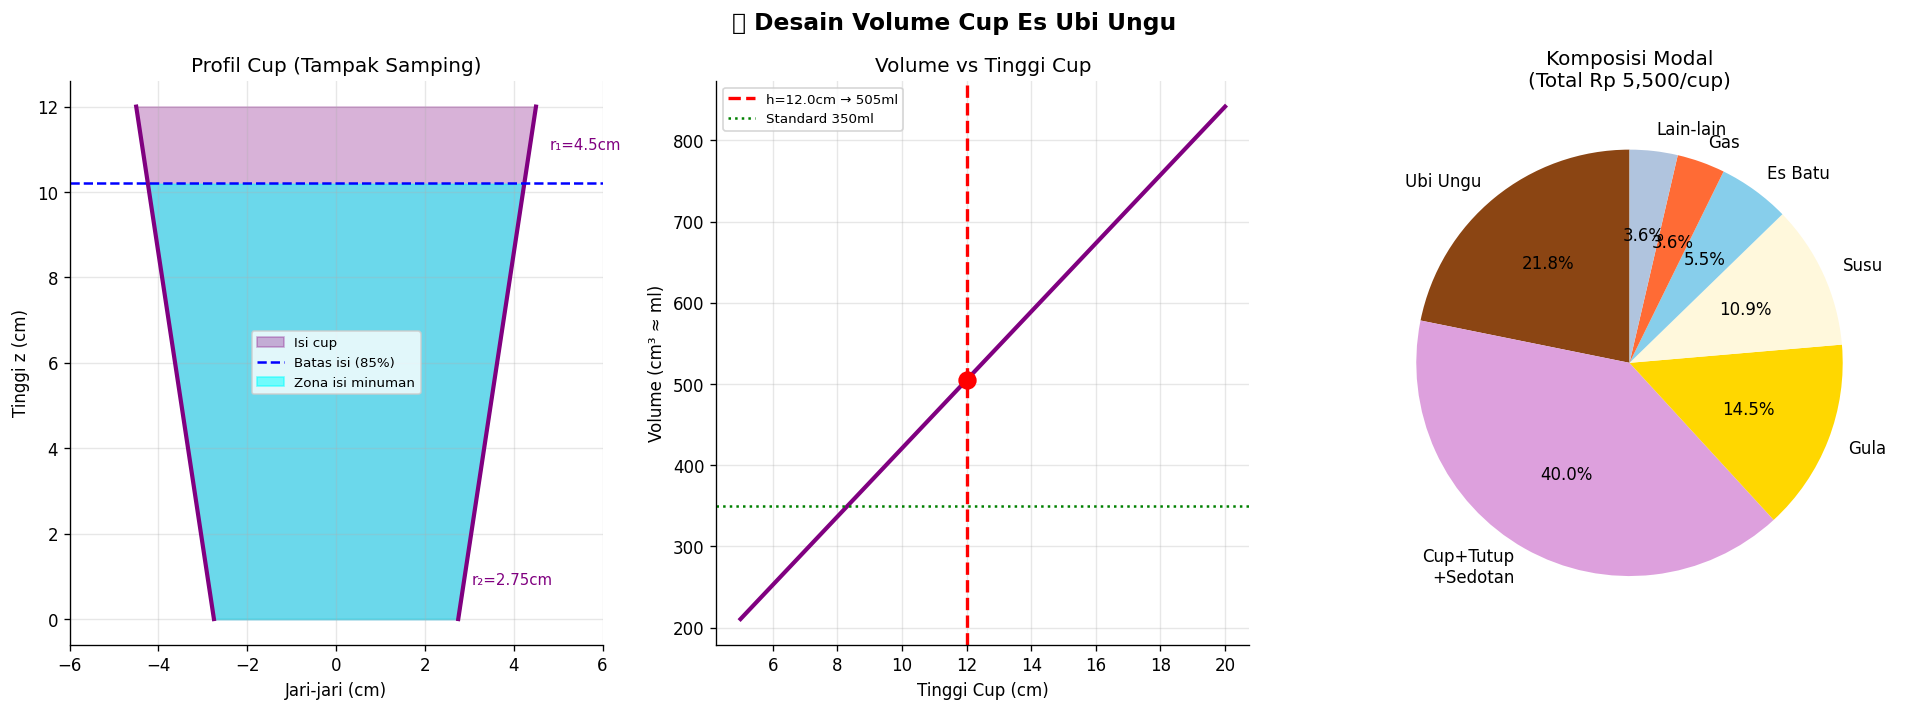

╔══════════════════════════════════════════════════════════════╗
║     🫙  VOLUME CUP — RUMUS & HASIL                         ║
╚══════════════════════════════════════════════════════════════╝

📌 RUMUS YANG DIPAKAI:
------------------------------------------------------------
  V = (π/3) × h × (r₁² + r₁r₂ + r₂²)
  di mana r₁ = jari-jari atas, r₂ = jari-jari bawah

📌 LANGKAH PERHITUNGAN:
------------------------------------------------------------
  Step 1 — r₁ = d_atas/2  = 9.0/2 = 4.5 cm
  Step 2 — r₂ = d_bawah/2 = 5.5/2 = 2.75 cm
  Step 3 — r₁² = 4.5² = 20.25
  Step 4 — r₁r₂ = 4.5×2.75 = 12.375
  Step 5 — r₂² = 2.75² = 7.5625
  Step 6 — r₁² + r₁r₂ + r₂² = 20.25 + 12.375 + 7.5625 = 40.1875
  Step 7 — V = (π/3) × 12.0 × 40.1875
         = 1.0472 × 12.0 × 40.1875
         = 505.0110 cm³

📌 HASIL:
------------------------------------------------------------
              Indikator                            Nilai
          Rumus Frustum            505.0110 cm³ ≈ 505 mL
Verifikasi via Inte

In [5]:
# ════════════════════════════════════════════════════════════════
# RUMUS YANG DIPAKAI:
#   V_frustum = (π/3) × h × (r₁² + r₁r₂ + r₂²)
# ════════════════════════════════════════════════════════════════

# Volume tabung terpancung (frustum)
V_frustum = (np.pi / 3) * tinggi * (r1**2 + r1*r2 + r2**2)

# Verifikasi via integral
r_z = lambda z: r2 + (r1 - r2) * (z / tinggi)         # jari-jari pada ketinggian z
V_integral, _ = integrate.quad(lambda z: np.pi * r_z(z)**2, 0, tinggi)

# Kapasitas isi (asumsi diisi 85% dari volume)
isi_persen = 0.85
V_isi = V_frustum * isi_persen

# Analisis berbagai ukuran cup
tinggi_arr = np.linspace(5, 20, 200)
V_arr_atas  = (np.pi/3) * tinggi_arr * (r1**2 + r1*r2 + r2**2)   # proporsi sama

# ─── VISUALISASI ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('🫙 Desain Volume Cup Es Ubi Ungu', fontsize=14, fontweight='bold')

# Plot 1: Profil cup
z_arr2 = np.linspace(0, tinggi, 200)
r_arr2 = r_z(z_arr2)
ax = axes[0]
ax.fill_betweenx(z_arr2, -r_arr2, r_arr2, alpha=0.3, color='purple', label='Isi cup')
ax.plot( r_arr2, z_arr2, 'purple', lw=2.5)
ax.plot(-r_arr2, z_arr2, 'purple', lw=2.5)
ax.axhline(tinggi * isi_persen, color='blue', ls='--', lw=1.5, label=f'Batas isi ({isi_persen*100:.0f}%)')
ax.fill_betweenx(z_arr2[z_arr2 <= tinggi*isi_persen], -r_z(z_arr2[z_arr2 <= tinggi*isi_persen]),
                 r_z(z_arr2[z_arr2 <= tinggi*isi_persen]), alpha=0.5, color='cyan', label='Zona isi minuman')
ax.annotate(f'r₁={r1}cm', xy=(r1, tinggi), xytext=(r1+0.3, tinggi-1), fontsize=9, color='purple')
ax.annotate(f'r₂={r2}cm', xy=(r2, 0), xytext=(r2+0.3, 0.8), fontsize=9, color='purple')
ax.set_xlabel('Jari-jari (cm)')
ax.set_ylabel('Tinggi z (cm)')
ax.set_title('Profil Cup (Tampak Samping)')
ax.legend(fontsize=8)
ax.set_xlim(-6, 6)

# Plot 2: Volume vs Tinggi
ax2 = axes[1]
ax2.plot(tinggi_arr, V_arr_atas, 'purple', lw=2.5)
ax2.axvline(tinggi, color='red', ls='--', lw=2, label=f'h={tinggi}cm → {V_frustum:.0f}ml')
ax2.axhline(350, color='green', ls=':', lw=1.5, label='Standard 350ml')
ax2.scatter([tinggi], [V_frustum], color='red', s=100, zorder=5)
ax2.set_xlabel('Tinggi Cup (cm)')
ax2.set_ylabel('Volume (cm³ ≈ ml)')
ax2.set_title('Volume vs Tinggi Cup')
ax2.legend(fontsize=8)

# Plot 3: Pie komposisi biaya cup
ax3 = axes[2]
bahan_labels = ['Ubi Ungu', 'Cup+Tutup\n+Sedotan', 'Gula', 'Susu', 'Es Batu', 'Gas', 'Lain-lain']
bahan_vals = [harga_ubi_per_cup, biaya_cup_total_per_pcs, biaya_gula_per_cup,
              biaya_susu_per_cup, biaya_es_batu_per_cup, biaya_gas_per_cup, biaya_lain_per_cup]
colors_pie = ['#8B4513', '#DDA0DD', '#FFD700', '#FFF8DC', '#87CEEB', '#FF6B35', '#B0C4DE']
wedges, texts, autotexts = ax3.pie(bahan_vals, labels=bahan_labels, autopct='%1.1f%%',
                                    colors=colors_pie, startangle=90)
ax3.set_title(f'Komposisi Modal\n(Total Rp {modal_per_cup:,.0f}/cup)')

plt.tight_layout()
plt.show()

# ─── OUTPUT RUMUS + HASIL ─────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║     🫙  VOLUME CUP — RUMUS & HASIL                         ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📌 RUMUS YANG DIPAKAI:")
print("-" * 60)
print("  V = (π/3) × h × (r₁² + r₁r₂ + r₂²)")
print("  di mana r₁ = jari-jari atas, r₂ = jari-jari bawah")

print("\n📌 LANGKAH PERHITUNGAN:")
print("-" * 60)
print(f"  Step 1 — r₁ = d_atas/2  = {d_atas}/2 = {r1} cm")
print(f"  Step 2 — r₂ = d_bawah/2 = {d_bawah}/2 = {r2} cm")
print(f"  Step 3 — r₁² = {r1}² = {r1**2}")
print(f"  Step 4 — r₁r₂ = {r1}×{r2} = {r1*r2}")
print(f"  Step 5 — r₂² = {r2}² = {r2**2}")
print(f"  Step 6 — r₁² + r₁r₂ + r₂² = {r1**2} + {r1*r2} + {r2**2} = {r1**2 + r1*r2 + r2**2}")
print(f"  Step 7 — V = (π/3) × {tinggi} × {r1**2 + r1*r2 + r2**2}")
print(f"         = {np.pi/3:.4f} × {tinggi} × {r1**2 + r1*r2 + r2**2}")
print(f"         = {V_frustum:.4f} cm³")

print("\n📌 HASIL:")
print("-" * 60)
hasil_vol = {
    'Rumus Frustum': f'{V_frustum:.4f} cm³ ≈ {V_frustum:.0f} mL',
    'Verifikasi via Integral': f'{V_integral:.4f} cm³ (selisih: {abs(V_frustum-V_integral):.6f})',
    'Kapasitas Isi (85%)': f'{V_isi:.1f} mL ≈ {V_isi:.0f} mL',
    'Diameter Atas': f'{d_atas} cm',
    'Diameter Bawah': f'{d_bawah} cm',
    'Tinggi Cup': f'{tinggi} cm',
    'Kategori Ukuran': 'Medium (250-350 mL)' if 250 <= V_isi <= 350 else 'Di luar standar medium'
}
df_vol = pd.DataFrame(list(hasil_vol.items()), columns=['Indikator', 'Nilai'])
print(df_vol.to_string(index=False))

print("\n💡 ARTINYA (bahasa awam):")
print(f"   → Cup ini muat sekitar {V_frustum:.0f} mL jika diisi penuh.")
print(f"   → Jika diisi 85% (standar agar tidak tumpah), isinya ≈ {V_isi:.0f} mL.")
print(f"   → Ini setara dengan {V_isi/240:.2f} gelas belimbing (1 gelas = 240 mL).")
print("═" * 60)

---
## 4. 📈 Model Pertumbuhan Penjualan (Eksponensial)

### 📚 Rumus:
$$P(t) = P_0 \cdot e^{rt}$$
$$P'(t) = r \cdot P_0 \cdot e^{rt} = r \cdot P(t) \quad \text{(laju pertumbuhan sesaat)}$$
$$\text{Total Akumulasi} = \int_0^T P_0 \cdot e^{rt} \, dt = \frac{P_0}{r}(e^{rT} - 1)$$

### 💡 Penjelasan untuk orang awam:
> Model eksponensial cocok kalau bisnismu tumbuh **makin lama makin cepat** — misalnya karena pelanggan merekomendasikan ke teman-teman. Ibarat bunga berbunga: makin banyak pelanggan, makin banyak lagi yang datang. **r = laju pertumbuhan** — kalau r = 5%, artinya penjualan naik 5% setiap hari.

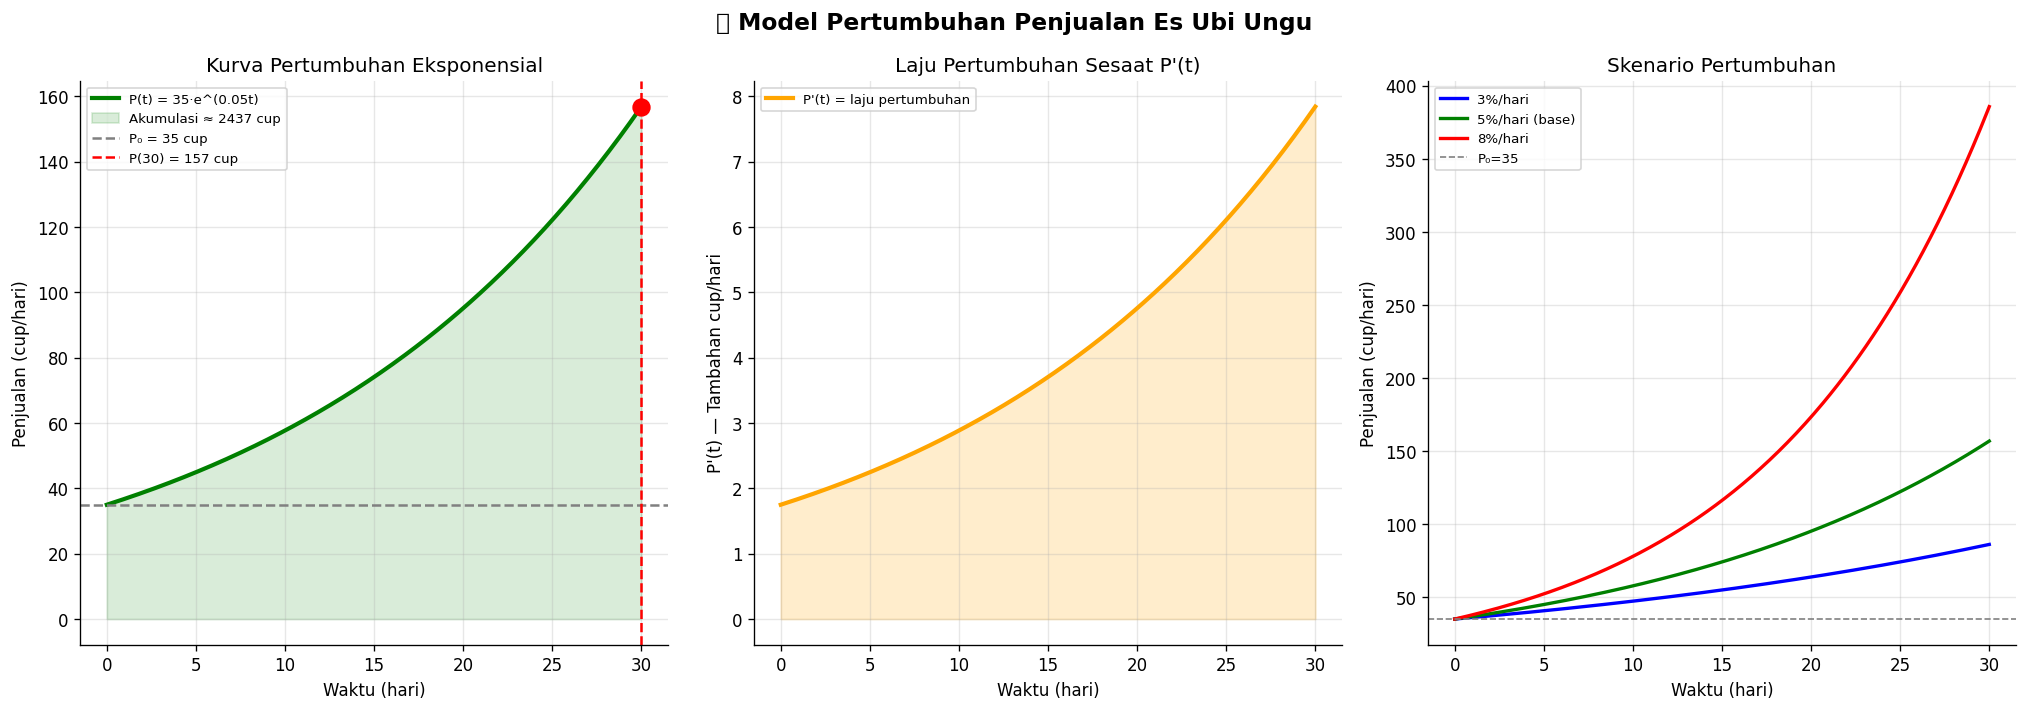

╔══════════════════════════════════════════════════════════════╗
║     📈  MODEL EKSPONENSIAL — RUMUS & HASIL                 ║
╚══════════════════════════════════════════════════════════════╝

📌 RUMUS YANG DIPAKAI:
------------------------------------------------------------
  P(t)   = P₀ × e^(rt)             ← jumlah penjualan hari ke-t
  P'(t)  = r × P₀ × e^(rt)         ← laju penambahan penjualan
  ∫P(t)dt= (P₀/r)(e^rT − 1)        ← total kumulatif penjualan

📌 LANGKAH PERHITUNGAN:
------------------------------------------------------------
  P₀ = 35 cup/hari (penjualan awal)
  r  = 0.05 (5%/hari)
  T  = 30 hari
  P(30) = 35 × e^(0.05×30) = 35 × 4.4817 = 156.86 cup
  Akumulasi = (35/0.05) × (e^(0.05×30) − 1)
            = 700 × (4.4817 − 1)
            = 2437.18 cup

📌 TABEL PROYEKSI PENJUALAN:
------------------------------------------------------------
 Hari ke- Cup/Hari Revenue Hari Itu Pertumbuhan vs H1
        1       37       Rp 367,945             +5.1%
        7       50   

In [6]:
# ════════════════════════════════════════════════════════════════
# RUMUS YANG DIPAKAI:
#   P(t) = P₀ × e^(rt)
#   Total akumulasi = ∫[0→T] P₀·e^(rt) dt = (P₀/r)(e^rT − 1)
# ════════════════════════════════════════════════════════════════

P0       = cup_terjual_per_hari   # penjualan awal = 35 cup/hari
r_growth = 0.05                   # laju pertumbuhan 5%/hari
T        = 30                     # proyeksi 30 hari

t_arr   = np.linspace(0, T, 300)
P_t     = P0 * np.exp(r_growth * t_arr)
P_T     = P0 * np.exp(r_growth * T)
dP_dt   = r_growth * P_t                                    # turunan P'(t)

# Total akumulasi (integral analitik & numerik)
total_akum_analitik = (P0 / r_growth) * (np.exp(r_growth * T) - 1)
total_akum_numerik, _ = integrate.quad(lambda t: P0 * np.exp(r_growth * t), 0, T)

# Revenue dari akumulasi
revenue_akum = total_akum_analitik * harga_jual

# ─── VISUALISASI ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('📈 Model Pertumbuhan Penjualan Es Ubi Ungu', fontsize=14, fontweight='bold')

# Plot 1: Kurva P(t)
ax = axes[0]
ax.plot(t_arr, P_t, 'g-', lw=2.5, label=f'P(t) = {P0}·e^({r_growth}t)')
ax.fill_between(t_arr, P_t, alpha=0.15, color='green', label=f'Akumulasi ≈ {total_akum_analitik:.0f} cup')
ax.axhline(P0, color='gray', ls='--', lw=1.5, label=f'P₀ = {P0} cup')
ax.axvline(T,  color='red', ls='--', lw=1.5, label=f'P({T}) = {P_T:.0f} cup')
ax.scatter([T], [P_T], s=100, color='red', zorder=5)
ax.set_xlabel('Waktu (hari)')
ax.set_ylabel('Penjualan (cup/hari)')
ax.set_title('Kurva Pertumbuhan Eksponensial')
ax.legend(fontsize=8)

# Plot 2: Turunan P'(t)
ax2 = axes[1]
ax2.plot(t_arr, dP_dt, 'orange', lw=2.5, label="P'(t) = laju pertumbuhan")
ax2.fill_between(t_arr, dP_dt, alpha=0.2, color='orange')
ax2.set_xlabel('Waktu (hari)')
ax2.set_ylabel("P'(t) — Tambahan cup/hari")
ax2.set_title("Laju Pertumbuhan Sesaat P'(t)")
ax2.legend(fontsize=8)

# Plot 3: Perbandingan skenario pertumbuhan
ax3 = axes[2]
for r_val, lbl, col in [(0.03, '3%/hari', 'blue'), (0.05, '5%/hari (base)', 'green'), (0.08, '8%/hari', 'red')]:
    P_skenario = P0 * np.exp(r_val * t_arr)
    ax3.plot(t_arr, P_skenario, lw=2, color=col, label=lbl)
ax3.axhline(P0, color='gray', ls='--', lw=1, label=f'P₀={P0}')
ax3.set_xlabel('Waktu (hari)')
ax3.set_ylabel('Penjualan (cup/hari)')
ax3.set_title('Skenario Pertumbuhan')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ─── OUTPUT RUMUS + HASIL ─────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║     📈  MODEL EKSPONENSIAL — RUMUS & HASIL                 ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📌 RUMUS YANG DIPAKAI:")
print("-" * 60)
print("  P(t)   = P₀ × e^(rt)             ← jumlah penjualan hari ke-t")
print("  P'(t)  = r × P₀ × e^(rt)         ← laju penambahan penjualan")
print("  ∫P(t)dt= (P₀/r)(e^rT − 1)        ← total kumulatif penjualan")

print("\n📌 LANGKAH PERHITUNGAN:")
print("-" * 60)
print(f"  P₀ = {P0} cup/hari (penjualan awal)")
print(f"  r  = {r_growth} ({r_growth*100:.0f}%/hari)")
print(f"  T  = {T} hari")
print(f"  P({T}) = {P0} × e^({r_growth}×{T}) = {P0} × {np.exp(r_growth*T):.4f} = {P_T:.2f} cup")
print(f"  Akumulasi = ({P0}/{r_growth}) × (e^({r_growth}×{T}) − 1)")
print(f"            = {P0/r_growth:.0f} × ({np.exp(r_growth*T):.4f} − 1)")
print(f"            = {total_akum_analitik:.2f} cup")

print("\n📌 TABEL PROYEKSI PENJUALAN:")
print("-" * 60)
hari_check = [1, 7, 14, 21, 30]
proj_data = {
    'Hari ke-': hari_check,
    'Cup/Hari': [f'{P0 * np.exp(r_growth * h):.0f}' for h in hari_check],
    'Revenue Hari Itu': [f'Rp {P0 * np.exp(r_growth * h) * harga_jual:,.0f}' for h in hari_check],
    'Pertumbuhan vs H1': [f'+{(np.exp(r_growth*h)-1)*100:.1f}%' for h in hari_check]
}
df_proj = pd.DataFrame(proj_data)
print(df_proj.to_string(index=False))

print("\n📌 RINGKASAN HASIL:")
print("-" * 60)
print(f"  Penjualan Awal P₀         : {P0} cup/hari")
print(f"  Laju Pertumbuhan          : {r_growth*100:.0f}%/hari")
print(f"  Penjualan Hari ke-{T}      : {P_T:.0f} cup/hari")
print(f"  Total Akumulasi 30 hari   : {total_akum_analitik:.0f} cup")
print(f"  Estimasi Revenue 30 hari  : Rp {revenue_akum:,.0f}")
print(f"  Verifikasi (numerik)      : {total_akum_numerik:.0f} cup (selisih: {abs(total_akum_analitik-total_akum_numerik):.4f})")

print("\n💡 ARTINYA (bahasa awam):")
print(f"   → Kalau penjualan naik 5% tiap hari, dari {P0} cup di hari pertama")
print(f"     akan jadi {P_T:.0f} cup di hari ke-30.")
print(f"   → Total penjualan selama 30 hari = {total_akum_analitik:.0f} cup ≈ Rp {revenue_akum:,.0f}")
print("═" * 60)

---
## 5. 🎯 Optimasi Keuntungan (Turunan Pertama = 0)

### 📚 Rumus:
$$\pi(q) = TR(q) - TC(q) = (p - aq) \cdot q - VC \cdot q - FC$$

Syarat profit maksimum (turunan pertama = 0):
$$\frac{d\pi}{dq} = p - 2aq - VC = 0 \implies q^* = \frac{p - VC}{2a}$$

Syarat cukup (turunan kedua negatif = maksimum):
$$\frac{d^2\pi}{dq^2} = -2a < 0 \quad \checkmark$$

### 💡 Penjelasan untuk orang awam:
> Semakin banyak cup kamu jual, harga di pasaran bisa turun (kalau kamu sendiri supplier). Model kuadratik menangkap realita ini. **q*** adalah jumlah produksi yang paling menguntungkan — seperti titik puncak gunung. Di bawah atau di atasnya, keuntungan berkurang.

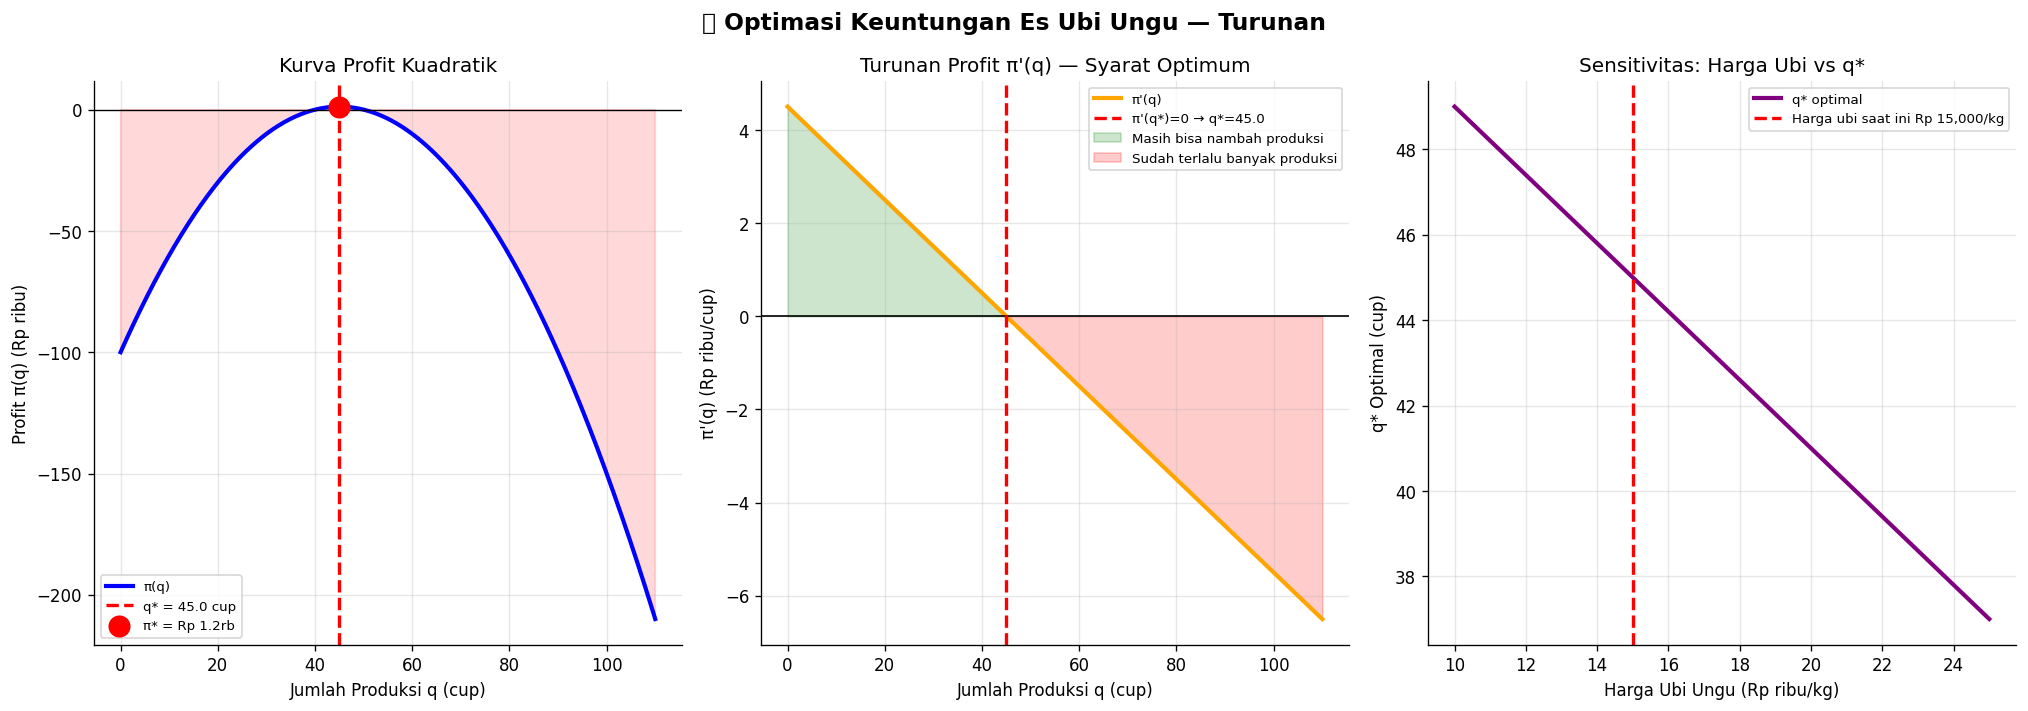

╔══════════════════════════════════════════════════════════════╗
║     🎯  OPTIMASI KEUNTUNGAN — RUMUS & HASIL                ║
╚══════════════════════════════════════════════════════════════╝

📌 RUMUS YANG DIPAKAI:
------------------------------------------------------------
  π(q) = (p − aq)·q − VC·q − FC
       = (10000 − 50q)·q − 5,500·q − 100000
  π'(q) = p − 2aq − VC  (turunan pertama)
  Syarat: π'(q*) = 0
  → 10000 − 2×50×q − 5,500 = 0
  → q* = (p − VC) / (2a) = (10000 − 5,500) / (2×50)
  → q* = 4,500 / 100 = 45.00 cup
  π''(q) = −2a = −100 < 0 → MAKSIMUM ✓

📌 TABEL PERBANDINGAN PRODUKSI:
------------------------------------------------------------
    Skenario  Jumlah Cup (q) Profit (Rp) vs Profit Optimal
      50% q*              22     -25,200          -2116.0%
      75% q*              33      -5,950           -576.0%
q* (OPTIMAL)              45       1,250             +0.0%
     125% q*              56      -4,800           -484.0%
     150% q*              67     -22,950  

In [7]:
# ════════════════════════════════════════════════════════════════
# RUMUS YANG DIPAKAI:
#   π(q) = (p − aq)q − VC·q − FC
#   Syarat optimum: dπ/dq = 0 → q* = (p − VC) / (2a)
# ════════════════════════════════════════════════════════════════

a_coef  = 50    # koefisien demand (harga turun Rp 50 per tambahan cup)
                # p(q) = harga_jual − a_coef × q

# Fungsi profit kuadratik
pi_q   = lambda q: (harga_jual - a_coef * q) * q - modal_per_cup * q - total_biaya_tetap
dpi_dq = lambda q: harga_jual - 2 * a_coef * q - modal_per_cup   # turunan pertama
d2pi   = -2 * a_coef                                               # turunan kedua (konstan)

# Titik optimal analitik
q_star  = (harga_jual - modal_per_cup) / (2 * a_coef)
pi_star = pi_q(q_star)

q_range = np.linspace(0, 2 * q_star + 20, 400)

# ─── VISUALISASI ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('🎯 Optimasi Keuntungan Es Ubi Ungu — Turunan', fontsize=14, fontweight='bold')

# Plot 1: Kurva Profit
ax = axes[0]
ax.plot(q_range, pi_q(q_range)/1000, 'b-', lw=2.5, label='π(q)')
ax.axhline(0, color='k', lw=0.8)
ax.axvline(q_star, color='red', ls='--', lw=2, label=f'q* = {q_star:.1f} cup')
ax.scatter([q_star], [pi_star/1000], s=150, color='red', zorder=6,
           label=f'π* = Rp {pi_star/1000:.1f}rb')
ax.fill_between(q_range, pi_q(q_range)/1000, 0, where=(pi_q(q_range) > 0), alpha=0.15, color='green')
ax.fill_between(q_range, pi_q(q_range)/1000, 0, where=(pi_q(q_range) <= 0), alpha=0.15, color='red')
ax.set_xlabel('Jumlah Produksi q (cup)')
ax.set_ylabel('Profit π(q) (Rp ribu)')
ax.set_title('Kurva Profit Kuadratik')
ax.legend(fontsize=8)

# Plot 2: Turunan π'(q)
ax2 = axes[1]
ax2.plot(q_range, dpi_dq(q_range)/1000, 'orange', lw=2.5, label="π'(q)")
ax2.axhline(0, color='k', lw=1)
ax2.axvline(q_star, color='red', ls='--', lw=2, label=f"π'(q*)=0 → q*={q_star:.1f}")
ax2.fill_between(q_range, dpi_dq(q_range)/1000, 0, where=(dpi_dq(q_range) > 0), alpha=0.2, color='green', label='Masih bisa nambah produksi')
ax2.fill_between(q_range, dpi_dq(q_range)/1000, 0, where=(dpi_dq(q_range) <= 0), alpha=0.2, color='red', label='Sudah terlalu banyak produksi')
ax2.set_xlabel('Jumlah Produksi q (cup)')
ax2.set_ylabel("π'(q) (Rp ribu/cup)")
ax2.set_title("Turunan Profit π'(q) — Syarat Optimum")
ax2.legend(fontsize=8)

# Plot 3: Analisis sensitivitas harga ubi
ax3 = axes[2]
harga_ubi_range = np.linspace(10000, 25000, 100)
q_star_ubi = []
pi_star_ubi = []
for h_ubi in harga_ubi_range:
    vc_new = h_ubi * kebutuhan_ubi_per_cup + biaya_cup_total_per_pcs + biaya_gula_per_cup + biaya_susu_per_cup + biaya_es_batu_per_cup + biaya_gas_per_cup + biaya_lain_per_cup
    q_s = (harga_jual - vc_new) / (2 * a_coef) if harga_jual > vc_new else 0
    q_star_ubi.append(q_s)
    pi_s = (harga_jual - a_coef * q_s) * q_s - vc_new * q_s - total_biaya_tetap if q_s > 0 else -total_biaya_tetap
    pi_star_ubi.append(pi_s / 1000)
ax3.plot(harga_ubi_range/1000, q_star_ubi, 'purple', lw=2.5, label='q* optimal')
ax3.axvline(harga_ubi_per_kg/1000, color='red', ls='--', lw=2, label=f'Harga ubi saat ini Rp {harga_ubi_per_kg:,}/kg')
ax3.set_xlabel('Harga Ubi Ungu (Rp ribu/kg)')
ax3.set_ylabel('q* Optimal (cup)')
ax3.set_title('Sensitivitas: Harga Ubi vs q*')
ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ─── OUTPUT RUMUS + HASIL ─────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║     🎯  OPTIMASI KEUNTUNGAN — RUMUS & HASIL                ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📌 RUMUS YANG DIPAKAI:")
print("-" * 60)
print(f"  π(q) = (p − aq)·q − VC·q − FC")
print(f"       = ({harga_jual} − {a_coef}q)·q − {modal_per_cup:,.0f}·q − {total_biaya_tetap}")
print(f"  π'(q) = p − 2aq − VC  (turunan pertama)")
print(f"  Syarat: π'(q*) = 0")
print(f"  → {harga_jual} − 2×{a_coef}×q − {modal_per_cup:,.0f} = 0")
print(f"  → q* = (p − VC) / (2a) = ({harga_jual} − {modal_per_cup:,.0f}) / (2×{a_coef})")
print(f"  → q* = {harga_jual - modal_per_cup:,.0f} / {2*a_coef} = {q_star:.2f} cup")
print(f"  π''(q) = −2a = −{2*a_coef} < 0 → MAKSIMUM ✓")

print("\n📌 TABEL PERBANDINGAN PRODUKSI:")
print("-" * 60)
q_scenarios = [int(q_star*0.5), int(q_star*0.75), int(q_star), int(q_star*1.25), int(q_star*1.5)]
comp_data = {
    'Skenario': ['50% q*', '75% q*', 'q* (OPTIMAL)', '125% q*', '150% q*'],
    'Jumlah Cup (q)': q_scenarios,
    'Profit (Rp)': [f'{pi_q(q):,.0f}' for q in q_scenarios],
    'vs Profit Optimal': [f'{(pi_q(q)/pi_star - 1)*100:+.1f}%' for q in q_scenarios]
}
df_opt = pd.DataFrame(comp_data)
print(df_opt.to_string(index=False))

print("\n📌 RINGKASAN HASIL:")
print("-" * 60)
print(f"  Produksi Optimal q*         : {q_star:.2f} cup")
print(f"  Profit Maksimum π*          : Rp {pi_star:,.2f}")
print(f"  Verifikasi π'(q*)           : {dpi_dq(q_star):.6f} ≈ 0 ✓")
print(f"  Turunan kedua π''(q)        : {d2pi} < 0 → maksimum ✓")

print("\n💡 ARTINYA (bahasa awam):")
print(f"   → Produksi paling menguntungkan = {q_star:.0f} cup/hari")
print(f"   → Profit maksimalnya = Rp {pi_star:,.0f}/hari")
print(f"   → Kalau produksi kurang atau lebih dari {q_star:.0f} cup, profit turun")
print("═" * 60)

---
## 6. 🤖 Model Machine Learning
### 6a. Regresi Polinomial — Prediksi Profit

### 📚 Rumus:
$$\hat{y} = \beta_0 + \beta_1 q + \beta_2 q^2 \quad \text{(Polynomial Degree 2)}$$
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$
$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

### 💡 Penjelasan untuk orang awam:
> ML di sini belajar dari **data historis** penjualan dan profit. Setelah belajar, model bisa **meramal** — kalau besok kamu produksi 70 cup, kira-kira profitnya berapa? R² mendekati 1 = model akurat. RMSE = rata-rata seberapa meleset prediksinya.

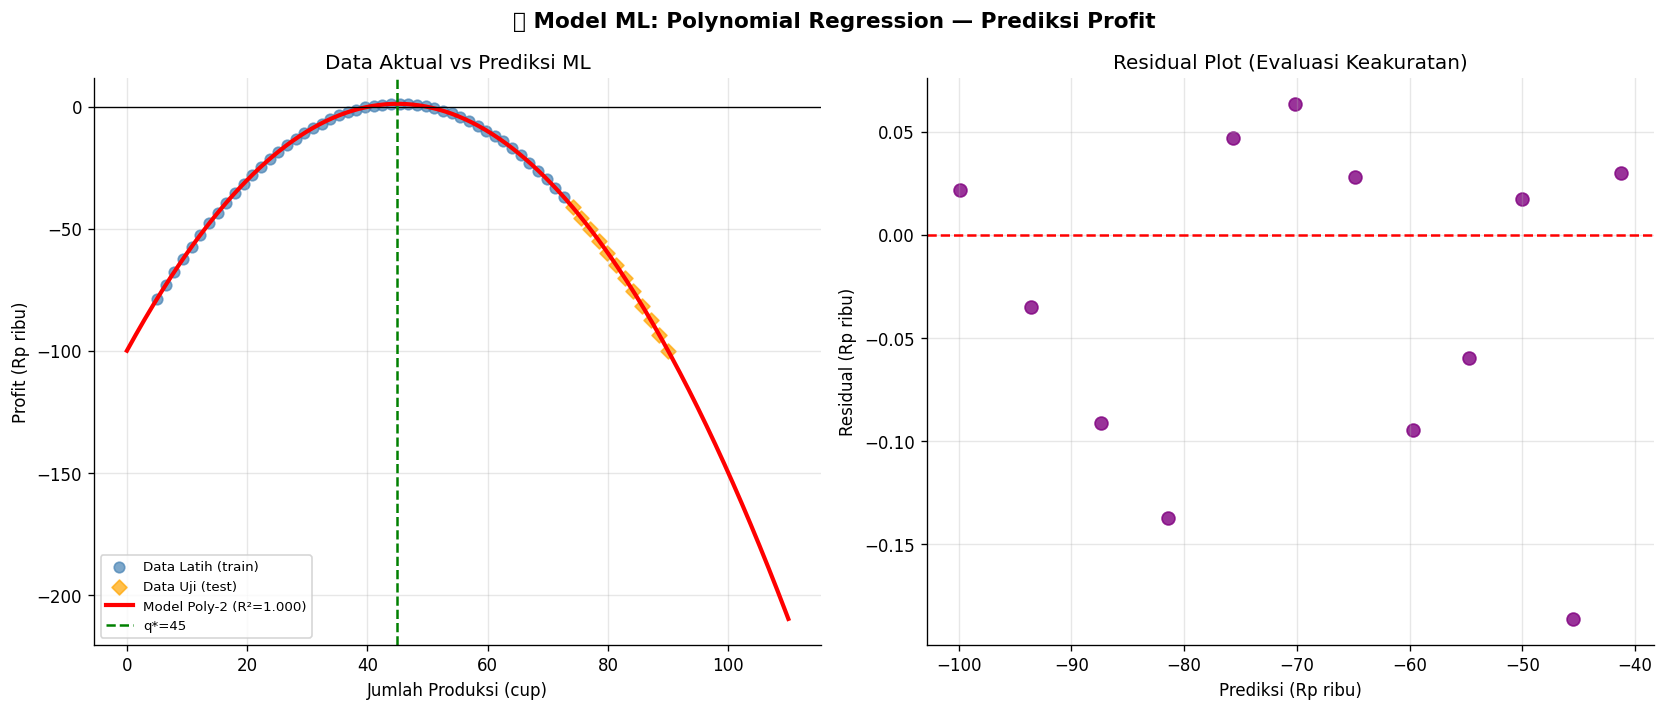

╔══════════════════════════════════════════════════════════════╗
║     🤖  MODEL ML POLYNOMIAL — RUMUS & HASIL               ║
╚══════════════════════════════════════════════════════════════╝

📌 RUMUS YANG DIPAKAI:
------------------------------------------------------------
  Model: ŷ = β₀ + β₁·q + β₂·q²
  RMSE = √( (1/n) · Σ(yᵢ − ŷᵢ)² )
  R²   = 1 − SS_res/SS_tot
  di mana SS_res = Σ(yᵢ−ŷᵢ)², SS_tot = Σ(yᵢ−ȳ)²

📌 KOEFISIEN MODEL YANG DITEMUKAN ML:
------------------------------------------------------------
  ŷ = -99924.70 + 4494.5667·q + -49.939581·q²

📌 METRIK EVALUASI MODEL:
------------------------------------------------------------
           Metrik    Nilai                              Interpretasi
         R² Score   1.0000 100.0% variasi data bisa dijelaskan model
             RMSE Rp 83.77                   Rata-rata meleset Rp 84
              MAE Rp 67.57             Rata-rata error absolut Rp 68
Jumlah Data Latih  48 data                    80% data untuk melatih
  Jumlah

In [8]:
# ════════════════════════════════════════════════════════════════
# MODEL: Polynomial Regression Degree 2
# Rumus: ŷ = β₀ + β₁q + β₂q²
# R² = 1 − SS_res/SS_tot
# RMSE = √(MSE)
# ════════════════════════════════════════════════════════════════

np.random.seed(42)

# Simulasi data historis produksi & profit (60 hari)
q_hist   = np.linspace(5, int(q_star*2), 60)
noise    = np.random.normal(0, pi_star * 0.08, 60)   # noise 8% dari profit maks
pi_hist  = pi_q(q_hist) + noise

# Train/Test Split 80/20
split = int(0.8 * len(q_hist))
X_train = q_hist[:split].reshape(-1, 1)
X_test  = q_hist[split:].reshape(-1, 1)
y_train = pi_hist[:split]
y_test  = pi_hist[split:]

# Model Polynomial Degree 2
model_poly = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
model_poly.fit(X_train, y_train)
y_pred = model_poly.predict(X_test)

# Metrik evaluasi
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = np.mean(np.abs(y_test - y_pred))

# Koefisien
lr_step = model_poly.named_steps['linearregression']
poly_step = model_poly.named_steps['polynomialfeatures']
coefs = lr_step.coef_
intercept = lr_step.intercept_

q_plot = np.linspace(0, int(q_star*2)+20, 300).reshape(-1, 1)
pi_pred_full = model_poly.predict(q_plot)

# ─── VISUALISASI ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('🤖 Model ML: Polynomial Regression — Prediksi Profit', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(q_hist[:split], pi_hist[:split]/1000, alpha=0.7, s=40, color='steelblue', label='Data Latih (train)')
ax.scatter(q_hist[split:], pi_hist[split:]/1000, alpha=0.7, s=40, color='orange', marker='D', label='Data Uji (test)')
ax.plot(q_plot, pi_pred_full/1000, 'r-', lw=2.5, label=f'Model Poly-2 (R²={r2:.3f})')
ax.axhline(0, color='k', lw=0.8)
ax.axvline(q_star, color='green', ls='--', lw=1.5, label=f'q*={q_star:.0f}')
ax.set_xlabel('Jumlah Produksi (cup)')
ax.set_ylabel('Profit (Rp ribu)')
ax.set_title('Data Aktual vs Prediksi ML')
ax.legend(fontsize=8)

# Plot: Residual
ax2 = axes[1]
residuals = y_test - y_pred
ax2.scatter(y_pred/1000, residuals/1000, alpha=0.8, color='purple', s=60)
ax2.axhline(0, color='red', lw=1.5, ls='--')
ax2.set_xlabel('Prediksi (Rp ribu)')
ax2.set_ylabel('Residual (Rp ribu)')
ax2.set_title('Residual Plot (Evaluasi Keakuratan)')

plt.tight_layout()
plt.show()

# ─── OUTPUT RUMUS + HASIL ─────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║     🤖  MODEL ML POLYNOMIAL — RUMUS & HASIL               ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📌 RUMUS YANG DIPAKAI:")
print("-" * 60)
print("  Model: ŷ = β₀ + β₁·q + β₂·q²")
print("  RMSE = √( (1/n) · Σ(yᵢ − ŷᵢ)² )")
print("  R²   = 1 − SS_res/SS_tot")
print("  di mana SS_res = Σ(yᵢ−ŷᵢ)², SS_tot = Σ(yᵢ−ȳ)²")

print("\n📌 KOEFISIEN MODEL YANG DITEMUKAN ML:")
print("-" * 60)
print(f"  ŷ = {intercept:.2f} + {coefs[1]:.4f}·q + {coefs[2]:.6f}·q²")

print("\n📌 METRIK EVALUASI MODEL:")
print("-" * 60)
eval_data = {
    'Metrik': ['R² Score', 'RMSE', 'MAE', 'Jumlah Data Latih', 'Jumlah Data Uji'],
    'Nilai': [f'{r2:.4f}', f'Rp {rmse:,.2f}', f'Rp {mae:,.2f}', f'{split} data', f'{len(q_hist)-split} data'],
    'Interpretasi': [
        f'{r2*100:.1f}% variasi data bisa dijelaskan model',
        f'Rata-rata meleset Rp {rmse:,.0f}',
        f'Rata-rata error absolut Rp {mae:,.0f}',
        '80% data untuk melatih',
        '20% data untuk uji'
    ]
}
df_eval = pd.DataFrame(eval_data)
print(df_eval.to_string(index=False))

print("\n📌 PREDIKSI UNTUK BERBAGAI JUMLAH PRODUKSI:")
print("-" * 60)
q_prediksi = [10, 20, int(q_star), 50, 70, 100]
pred_data = {
    'Jumlah Cup (q)': q_prediksi,
    'Prediksi Profit (ML)': [f'Rp {model_poly.predict([[q]])[0]:,.0f}' for q in q_prediksi],
    'Profit Teori (rumus)': [f'Rp {pi_q(q):,.0f}' for q in q_prediksi],
    'Selisih': [f'Rp {abs(model_poly.predict([[q]])[0] - pi_q(q)):,.0f}' for q in q_prediksi]
}
df_pred = pd.DataFrame(pred_data)
print(df_pred.to_string(index=False))

print("\n💡 ARTINYA (bahasa awam):")
print(f"   → Model ML berhasil 'menghafal' pola data dengan R² = {r2:.3f}")
print(f"   → Artinya model akurat {r2*100:.1f}% dalam memprediksi profit")
print(f"   → Rata-rata meleset hanya Rp {rmse:,.0f} dari profit sesungguhnya")
print("═" * 60)

---
### 6b. Model ML — Prediksi Pertumbuhan Penjualan (Time Series)

### 📚 Rumus:
$$\hat{P}(t) = \beta_0 + \beta_1 t + \beta_2 t^2 + \beta_3 \ln(t) \quad \text{(Ridge Regression)}$$
$$\text{Regularisasi Ridge: } \min \sum(y - \hat{y})^2 + \alpha \sum \beta_j^2$$

### 💡 Penjelasan untuk orang awam:
> Model ini seperti **prakiraan cuaca**, tapi untuk penjualanmu. Dengan data penjualan 60 hari pertama, model bisa meramal 30 hari ke depan. Ridge Regression adalah versi Linear Regression yang lebih 'hati-hati' — tidak mudah overfit (tidak gampang terlalu yakin berlebihan).

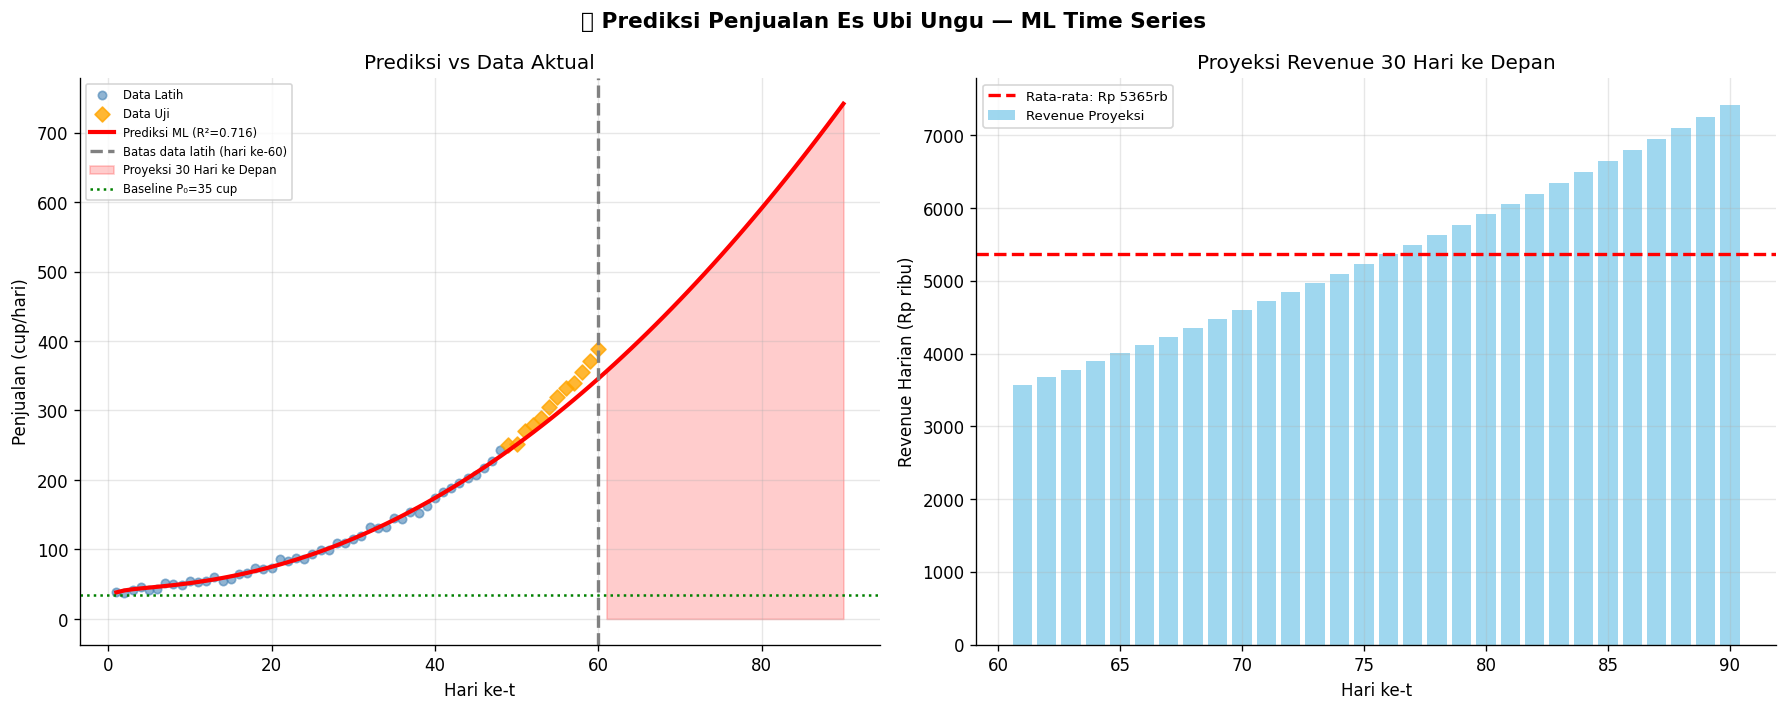

╔══════════════════════════════════════════════════════════════╗
║     📈  ML TIME SERIES — RUMUS & HASIL                    ║
╚══════════════════════════════════════════════════════════════╝

📌 RUMUS YANG DIPAKAI:
------------------------------------------------------------
  Fitur: X = [t,  t²,  ln(t)]
  Model: P̂(t) = β₀ + β₁·t + β₂·t² + β₃·ln(t)
  Ridge: min Σ(y − P̂)² + α·(β₁² + β₂² + β₃²)
  Alpha (regularisasi): α = 1.0

📌 KOEFISIEN MODEL:
------------------------------------------------------------
  β₁ (t) = -0.766542
  β₂ (t²) = 0.092595
  β₃ (ln t) = 4.816507
  β₀ (intercept) = 38.8432

📌 METRIK EVALUASI:
------------------------------------------------------------
  R² Score    : 0.7158 (71.6% akurasi)
  RMSE        : 23.55 cup

📌 PROYEKSI 30 HARI KE DEPAN:
------------------------------------------------------------
 Hari ke- Prediksi Cup Prediksi Revenue
       61          356     Rp 3,564,289
       65          400     Rp 4,003,363
       70          459     Rp 4,593,620
 

In [9]:
# ════════════════════════════════════════════════════════════════
# MODEL: Ridge Regression dengan fitur [t, t², ln(t)]
# Regularisasi: min Σ(y−ŷ)² + α·Σβⱼ²
# ════════════════════════════════════════════════════════════════

np.random.seed(42)
t_hist       = np.arange(1, 61).astype(float)
P_hist_true  = P0 * np.exp(0.04 * t_hist)
P_hist_noisy = P_hist_true + np.random.normal(0, P0 * 0.1, 60)   # noise 10%

# Buat fitur: [t, t², ln(t)]
def build_features(t):
    t = t.reshape(-1, 1)
    return np.hstack([t, t**2, np.log(t)])

X_ts    = build_features(t_hist)
split_ts = 48     # 48 hari latih, 12 hari uji
X_tr, X_te = X_ts[:split_ts], X_ts[split_ts:]
y_tr, y_te = P_hist_noisy[:split_ts], P_hist_noisy[split_ts:]

# Latih model Ridge
model_ts = Ridge(alpha=1.0)
model_ts.fit(X_tr, y_tr)

# Proyeksi 90 hari (30 hari ke depan)
t_future  = np.arange(1, 91).astype(float)
X_future  = build_features(t_future)
P_future  = model_ts.predict(X_future)

# Metrik
r2_ts   = r2_score(y_te, model_ts.predict(X_te))
rmse_ts = np.sqrt(mean_squared_error(y_te, model_ts.predict(X_te)))

# Revenue proyeksi
revenue_proyeksi_30hr = np.sum(P_future[60:]) * harga_jual   # 30 hari ke depan

# ─── VISUALISASI ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('📈 Prediksi Penjualan Es Ubi Ungu — ML Time Series', fontsize=13, fontweight='bold')

ax = axes[0]
ax.scatter(t_hist[:split_ts], P_hist_noisy[:split_ts], alpha=0.6, s=25, color='steelblue', label='Data Latih')
ax.scatter(t_hist[split_ts:], P_hist_noisy[split_ts:], alpha=0.8, s=40, color='orange', marker='D', label='Data Uji')
ax.plot(t_future, P_future, 'r-', lw=2.5, label=f'Prediksi ML (R²={r2_ts:.3f})')
ax.axvline(60, color='gray', ls='--', lw=2, label='Batas data latih (hari ke-60)')
ax.fill_between(t_future[t_future > 60], P_future[t_future > 60],
                alpha=0.2, color='red', label='Proyeksi 30 Hari ke Depan')
ax.axhline(P0, color='green', ls=':', lw=1.5, label=f'Baseline P₀={P0} cup')
ax.set_xlabel('Hari ke-t')
ax.set_ylabel('Penjualan (cup/hari)')
ax.set_title('Prediksi vs Data Aktual')
ax.legend(fontsize=7)

# Plot 2: Revenue proyeksi hari per hari
ax2 = axes[1]
hari_proyeksi  = t_future[60:]
rev_proyeksi   = P_future[60:] * harga_jual / 1000   # dalam ribu Rp
ax2.bar(hari_proyeksi, rev_proyeksi, color='skyblue', alpha=0.8, label='Revenue Proyeksi')
ax2.axhline(np.mean(rev_proyeksi), color='red', ls='--', lw=2, label=f'Rata-rata: Rp {np.mean(rev_proyeksi):.0f}rb')
ax2.set_xlabel('Hari ke-t')
ax2.set_ylabel('Revenue Harian (Rp ribu)')
ax2.set_title('Proyeksi Revenue 30 Hari ke Depan')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ─── OUTPUT RUMUS + HASIL ─────────────────────────────────────────
print("╔══════════════════════════════════════════════════════════════╗")
print("║     📈  ML TIME SERIES — RUMUS & HASIL                    ║")
print("╚══════════════════════════════════════════════════════════════╝")

print("\n📌 RUMUS YANG DIPAKAI:")
print("-" * 60)
print("  Fitur: X = [t,  t²,  ln(t)]")
print("  Model: P̂(t) = β₀ + β₁·t + β₂·t² + β₃·ln(t)")
print("  Ridge: min Σ(y − P̂)² + α·(β₁² + β₂² + β₃²)")
print(f"  Alpha (regularisasi): α = 1.0")

print("\n📌 KOEFISIEN MODEL:")
print("-" * 60)
coef_labels = ['β₁ (t)', 'β₂ (t²)', 'β₃ (ln t)']
for label, coef in zip(coef_labels, model_ts.coef_):
    print(f"  {label} = {coef:.6f}")
print(f"  β₀ (intercept) = {model_ts.intercept_:.4f}")

print("\n📌 METRIK EVALUASI:")
print("-" * 60)
print(f"  R² Score    : {r2_ts:.4f} ({r2_ts*100:.1f}% akurasi)")
print(f"  RMSE        : {rmse_ts:.2f} cup")

print("\n📌 PROYEKSI 30 HARI KE DEPAN:")
print("-" * 60)
hari_sample = [61, 65, 70, 75, 80, 85, 90]
proj30_data = {
    'Hari ke-': hari_sample,
    'Prediksi Cup': [f'{model_ts.predict(build_features(np.array([h])))[0]:.0f}' for h in hari_sample],
    'Prediksi Revenue': [f'Rp {model_ts.predict(build_features(np.array([h])))[0] * harga_jual:,.0f}' for h in hari_sample]
}
df_proj30 = pd.DataFrame(proj30_data)
print(df_proj30.to_string(index=False))
print(f"\n  Total Revenue Proyeksi 30 hari ke depan: Rp {revenue_proyeksi_30hr:,.0f}")

print("\n💡 ARTINYA (bahasa awam):")
print(f"   → Dari data 60 hari, model ramal 30 hari ke depan")
print(f"   → Di hari ke-90, prediksi penjualan = {P_future[-1]:.0f} cup/hari")
print(f"   → Total omzet yang diproyeksikan 30 hari ke depan: Rp {revenue_proyeksi_30hr:,.0f}")
print("═" * 60)

---
## 📊 Ringkasan Akhir — Semua Model

### 💡 Penjelasan untuk orang awam:
> Ini **laporan akhir** yang merangkum semua hasil analisis dalam satu tabel. Seperti rapor sekolah — semua nilai dikumpulkan jadi satu halaman. Kamu bisa tunjukkan ini ke investor atau bank sebagai bukti analisis keuangan yang terstruktur.

╔══════════════════════════════════════════════════════════════╗
║   🍠  LAPORAN LENGKAP — UMKM ES UBI UNGU                   ║
╚══════════════════════════════════════════════════════════════╝

📋 TABEL 1: STRUKTUR BIAYA PER CUP
----------------------------------------------------------
                             Item  Biaya/Cup (Rp) % dari Harga Jual
    Ubi Ungu (80g @ Rp 15.000/kg)          1200.0             12.0%
Cup Plastik (per lusin Rp 18.000)          1500.0             15.0%
                        Tutup Cup           500.0              5.0%
                          Sedotan           200.0              2.0%
                       Gula Pasir           800.0              8.0%
                Susu Kental Manis           600.0              6.0%
                          Es Batu           300.0              3.0%
                    Gas (alokasi)           200.0              2.0%
                        Lain-lain           200.0              2.0%
                         TOTAL MOD

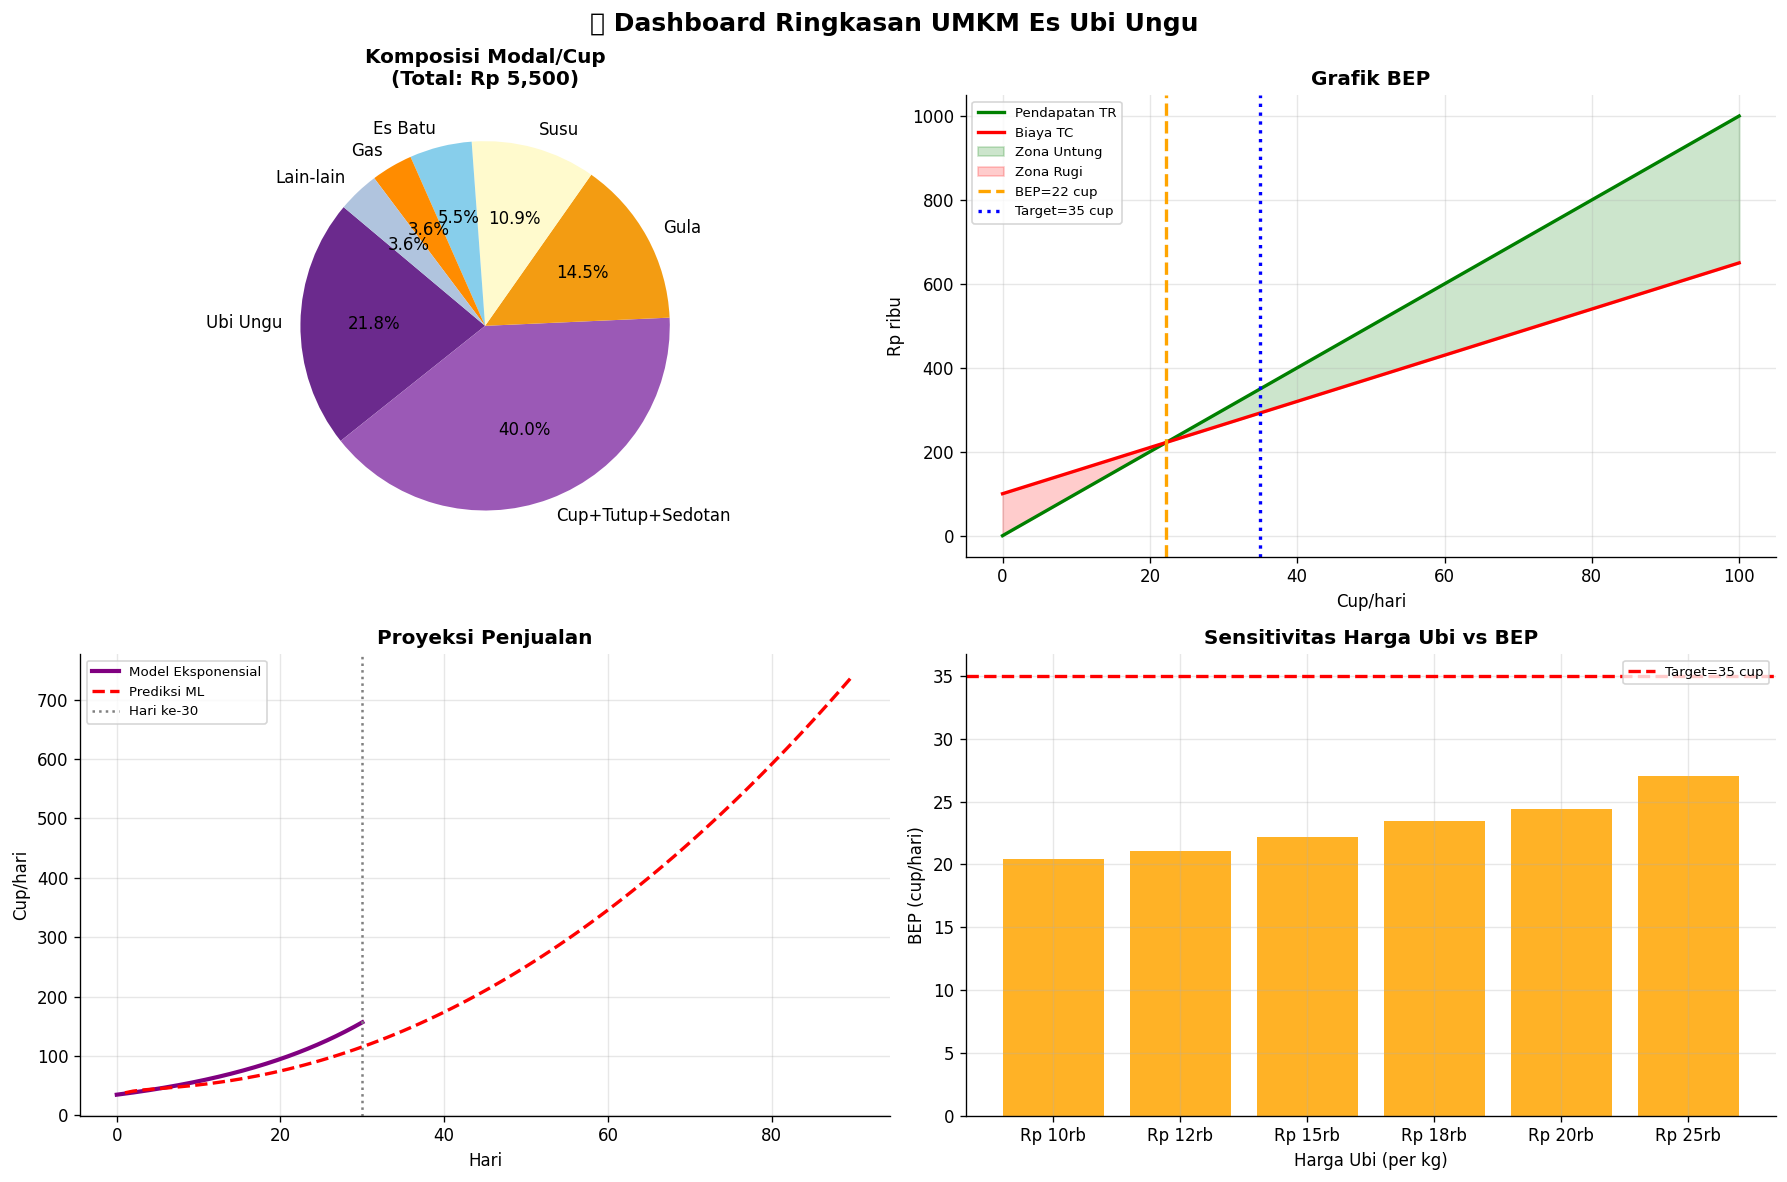


╔══════════════════════════════════════════════════════════════╗
║   🍠  KESIMPULAN UTAMA (Bahasa Awam)                       ║
╠══════════════════════════════════════════════════════════════╣
║  1. Modal per cup       : Rp 5,500                         ║
║  2. Keuntungan per cup  : Rp 4,500                        ║
║  3. BEP harian          : 22 cup (minimal jual ini dulu)   ║
║  4. Target harian       : 35 cup → profit Rp 57,500  ║
║  5. Produksi optimal    : 45 cup → profit maks Rp 1,250║
║  6. Akurasi ML Profit   : R² = 1.000 (100%)                    ║
║  7. Akurasi ML Penjualan: R² = 0.716 (72%)                   ║
╚══════════════════════════════════════════════════════════════╝


In [10]:
print("╔══════════════════════════════════════════════════════════════╗")
print("║   🍠  LAPORAN LENGKAP — UMKM ES UBI UNGU                   ║")
print("╚══════════════════════════════════════════════════════════════╝")

# ─── Tabel 1: Data Biaya ─────────────────────────────────────────
print("\n📋 TABEL 1: STRUKTUR BIAYA PER CUP")
print("-" * 58)
biaya_items = [
    ('Ubi Ungu (80g @ Rp 15.000/kg)', harga_ubi_per_cup, harga_ubi_per_cup/harga_jual*100),
    ('Cup Plastik (per lusin Rp 18.000)', harga_cup_per_pcs, harga_cup_per_pcs/harga_jual*100),
    ('Tutup Cup', harga_tutup_per_pcs, harga_tutup_per_pcs/harga_jual*100),
    ('Sedotan', harga_sedotan_per_pcs, harga_sedotan_per_pcs/harga_jual*100),
    ('Gula Pasir', biaya_gula_per_cup, biaya_gula_per_cup/harga_jual*100),
    ('Susu Kental Manis', biaya_susu_per_cup, biaya_susu_per_cup/harga_jual*100),
    ('Es Batu', biaya_es_batu_per_cup, biaya_es_batu_per_cup/harga_jual*100),
    ('Gas (alokasi)', biaya_gas_per_cup, biaya_gas_per_cup/harga_jual*100),
    ('Lain-lain', biaya_lain_per_cup, biaya_lain_per_cup/harga_jual*100),
]
df_biaya_akhir = pd.DataFrame(biaya_items, columns=['Item', 'Biaya/Cup (Rp)', '% dari Harga Jual'])
df_biaya_akhir['% dari Harga Jual'] = df_biaya_akhir['% dari Harga Jual'].map('{:.1f}%'.format)
print(df_biaya_akhir.to_string(index=False))
print(f"{'TOTAL MODAL/CUP':>40} {modal_per_cup:>10,.0f}  {modal_per_cup/harga_jual*100:.1f}%")
print(f"{'KEUNTUNGAN/CUP':>40} {keuntungan_per_cup:>10,.0f}  {keuntungan_per_cup/harga_jual*100:.1f}%")

# ─── Tabel 2: Hasil Semua Model ──────────────────────────────────
print("\n📊 TABEL 2: HASIL SEMUA MODEL ANALITIK")
print("-" * 58)
results_all = [
    ('Harga Jual per Cup', f'Rp {harga_jual:,.0f}', 'Input dasar'),
    ('Modal per Cup (VC)', f'Rp {modal_per_cup:,.0f}', 'Biaya variabel'),
    ('Biaya Tetap Harian (FC)', f'Rp {total_biaya_tetap:,.0f}', 'Biaya tetap'),
    ('Contribution Margin', f'Rp {contribution_margin:,.0f}/cup', 'p − VC'),
    ('BEP (titik impas)', f'{bep:.1f} cup/hari', '= FC/CM'),
    ('Target Produksi', f'{cup_terjual_per_hari} cup/hari', 'Dari omzet target'),
    ('Profit di target', f'Rp {profit(cup_terjual_per_hari):,.0f}', 'π(q_target)'),
    ('Luas Zona Untung', f'Rp {luas_untung:,.0f}', '∫[BEP→target] (TR−TC)dq'),
    ('Volume Cup', f'{V_frustum:.0f} mL ({V_isi:.0f} mL isi)', 'Frustum'),
    ('Proyeksi Penjualan (t=30)', f'{P_T:.0f} cup/hari', 'Model eksponensial'),
    ('Total Akumulasi 30 hari', f'{total_akum_analitik:.0f} cup', '∫P(t)dt'),
    ('q* Produksi Optimal', f'{q_star:.1f} cup/hari', 'dπ/dq = 0'),
    ('π* Profit Maksimum', f'Rp {pi_star:,.0f}/hari', 'Model kuadratik'),
    ('ML Poly R²', f'{r2:.4f} ({r2*100:.1f}%)', 'Akurasi prediksi profit'),
    ('ML Time-Series R²', f'{r2_ts:.4f} ({r2_ts*100:.1f}%)', 'Akurasi prediksi penjualan'),
    ('Revenue Proyeksi 30hr ke depan', f'Rp {revenue_proyeksi_30hr:,.0f}', 'ML forecast'),
]
df_all = pd.DataFrame(results_all, columns=['Indikator', 'Nilai', 'Keterangan'])
print(df_all.to_string(index=False))

# ─── Tabel 3: Skenario Harga Ubi ────────────────────────────────
print("\n🍠 TABEL 3: DAMPAK PERUBAHAN HARGA UBI UNGU TERHADAP BEP & PROFIT")
print("-" * 65)
harga_ubi_scenarios = [10000, 12000, 15000, 18000, 20000, 25000]
ubi_impact = []
for h in harga_ubi_scenarios:
    vc_new = h * kebutuhan_ubi_per_cup + biaya_cup_total_per_pcs + biaya_gula_per_cup + biaya_susu_per_cup + biaya_es_batu_per_cup + biaya_gas_per_cup + biaya_lain_per_cup
    cm_new = harga_jual - vc_new
    bep_new = total_biaya_tetap / cm_new if cm_new > 0 else float('inf')
    profit_35 = (harga_jual - vc_new) * 35 - total_biaya_tetap
    ubi_impact.append({
        'Harga Ubi (Rp/kg)': f'{h:,.0f}',
        'Modal/Cup (Rp)': f'{vc_new:,.0f}',
        'CM/Cup (Rp)': f'{cm_new:,.0f}',
        'BEP (cup)': f'{bep_new:.1f}' if cm_new > 0 else 'TIDAK EKONOMIS',
        'Profit @35cup (Rp)': f'{profit_35:,.0f}',
        'Status': '✅ Saat ini' if h == harga_ubi_per_kg else ('⚠️ Naik' if h > harga_ubi_per_kg else '💚 Turun')
    })
df_ubi_impact = pd.DataFrame(ubi_impact)
print(df_ubi_impact.to_string(index=False))

# ─── Visualisasi Ringkasan ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('🍠 Dashboard Ringkasan UMKM Es Ubi Ungu', fontsize=15, fontweight='bold')

# 1. Struktur biaya (pie)
ax1 = axes[0, 0]
bahan_l = ['Ubi Ungu', 'Cup+Tutup+Sedotan', 'Gula', 'Susu', 'Es Batu', 'Gas', 'Lain-lain']
bahan_v = [harga_ubi_per_cup, biaya_cup_total_per_pcs, biaya_gula_per_cup, biaya_susu_per_cup,
           biaya_es_batu_per_cup, biaya_gas_per_cup, biaya_lain_per_cup]
cols = ['#6B2A8D', '#9B59B6', '#F39C12', '#FFFACD', '#87CEEB', '#FF8C00', '#B0C4DE']
ax1.pie(bahan_v, labels=bahan_l, autopct='%1.1f%%', colors=cols, startangle=140)
ax1.set_title(f'Komposisi Modal/Cup\n(Total: Rp {modal_per_cup:,.0f})', fontweight='bold')

# 2. BEP Chart
ax2 = axes[0, 1]
q_plot2 = np.linspace(0, 100, 300)
ax2.plot(q_plot2, TR(q_plot2)/1000, 'g-', lw=2, label='Pendapatan TR')
ax2.plot(q_plot2, TC(q_plot2)/1000, 'r-', lw=2, label='Biaya TC')
ax2.fill_between(q_plot2, TC(q_plot2)/1000, TR(q_plot2)/1000,
                 where=(q_plot2 > bep), alpha=0.2, color='green', label='Zona Untung')
ax2.fill_between(q_plot2, TC(q_plot2)/1000, TR(q_plot2)/1000,
                 where=(q_plot2 <= bep), alpha=0.2, color='red', label='Zona Rugi')
ax2.axvline(bep, color='orange', ls='--', lw=2, label=f'BEP={bep:.0f} cup')
ax2.axvline(cup_terjual_per_hari, color='blue', ls=':', lw=2, label=f'Target={cup_terjual_per_hari} cup')
ax2.set_xlabel('Cup/hari')
ax2.set_ylabel('Rp ribu')
ax2.set_title('Grafik BEP', fontweight='bold')
ax2.legend(fontsize=8)

# 3. Proyeksi 30 hari
ax3 = axes[1, 0]
ax3.plot(t_arr, P_t, 'purple', lw=2.5, label='Model Eksponensial')
ax3.plot(t_future, P_future, 'r--', lw=2, label='Prediksi ML')
ax3.axvline(30, color='gray', ls=':', lw=1.5, label='Hari ke-30')
ax3.set_xlabel('Hari')
ax3.set_ylabel('Cup/hari')
ax3.set_title('Proyeksi Penjualan', fontweight='bold')
ax3.legend(fontsize=8)

# 4. Sensitivitas Harga Ubi
ax4 = axes[1, 1]
h_ubi_x = [10000, 12000, 15000, 18000, 20000, 25000]
bep_y = []
for h in h_ubi_x:
    vc_t = h * kebutuhan_ubi_per_cup + biaya_cup_total_per_pcs + biaya_gula_per_cup + biaya_susu_per_cup + biaya_es_batu_per_cup + biaya_gas_per_cup + biaya_lain_per_cup
    cm_t = harga_jual - vc_t
    bep_y.append(total_biaya_tetap / cm_t if cm_t > 0 else None)
bar_colors = ['green' if b is not None and b < 20 else 'orange' if b is not None and b < 30 else 'red' for b in bep_y]
bep_y_clean = [b if b is not None else 0 for b in bep_y]
ax4.bar([f'Rp {h//1000}rb' for h in h_ubi_x], bep_y_clean, color=bar_colors, alpha=0.85)
ax4.axhline(cup_terjual_per_hari, color='red', ls='--', lw=2, label=f'Target={cup_terjual_per_hari} cup')
ax4.set_xlabel('Harga Ubi (per kg)')
ax4.set_ylabel('BEP (cup/hari)')
ax4.set_title('Sensitivitas Harga Ubi vs BEP', fontweight='bold')
ax4.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ─── Pesan Akhir ─────────────────────────────────────────────────
print("\n╔══════════════════════════════════════════════════════════════╗")
print("║   🍠  KESIMPULAN UTAMA (Bahasa Awam)                       ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  1. Modal per cup       : Rp {modal_per_cup:,.0f}                         ║")
print(f"║  2. Keuntungan per cup  : Rp {keuntungan_per_cup:,.0f}                        ║")
print(f"║  3. BEP harian          : {bep:.0f} cup (minimal jual ini dulu)   ║")
print(f"║  4. Target harian       : {cup_terjual_per_hari} cup → profit Rp {profit(cup_terjual_per_hari):,.0f}  ║")
print(f"║  5. Produksi optimal    : {q_star:.0f} cup → profit maks Rp {pi_star:,.0f}║")
print(f"║  6. Akurasi ML Profit   : R² = {r2:.3f} ({r2*100:.0f}%)                    ║")
print(f"║  7. Akurasi ML Penjualan: R² = {r2_ts:.3f} ({r2_ts*100:.0f}%)                   ║")
print("╚══════════════════════════════════════════════════════════════╝")